In [1]:
%cd ..
import tangramlit as tgl

C:\Users\enric\tangram\.venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


C:\Users\enric\tangram


C:\Users\enric\tangram\.venv\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\Users\enric\tangram\.venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


In [2]:
import scanpy as sc

In [3]:
!uv pip install winshell

Audited 1 package in 82ms


In [4]:
import winshell
import os

shortcut_path = r"H:/Il mio Drive/dati_per_enrico.lnk"
real_path = winshell.shortcut(shortcut_path).path

print(f"Real path: {real_path}")

# Now test it
if os.path.exists(real_path):
    print("Resolved path is accessible")
else:
    print("Resolved path is not available")

Real path: H:\.shortcut-targets-by-id\1UGLL2UOn-9s1OY1r9mGMc1RFF7REij9e\dati_per_enrico
Resolved path is accessible


# Data loading

In [5]:
## Load pre-processed datasets
adata_sc = sc.read_h5ad("H:/Il mio Drive/data_tangram/counts100k_filt_pp_train_genes.h5ad")
adata_sc

AnnData object with n_obs × n_vars = 77337 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'spapros_probe', 'sparsity'
    uns: 'hvg', 'neighbors', 'pca', 'training_genes', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [6]:
adata_st = sc.read_h5ad("H:/Il mio Drive/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

# Baseline Model

In [7]:
ad_map_baseline_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=10,
    lambda_d=1,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1,
    lambda_f_reg=1,
    target_count=None,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                  | 0/10 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:  10%|███████▍                                                                  | 1/10 [00:36<05:27, 36.34s/it]

Epoch 0: {'Total loss': 52463.3359375, 'Score': 0.5169240832328796, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


Trainig: 100%|█████████████████████████████████████████████████████████████████████████| 10/10 [02:54<00:00, 17.42s/it]


Initial value of total_loss 52463.3359375
Initial value of main_loss 0.5169240832328796
Initial value of vg_reg 0.5125992894172668
Initial value of kl_reg 1.3388926163315773e-05
Initial value of entropy_reg -0.0
Initial value of l1_term 0.0
Initial value of l2_term 0.0
Initial value of count_reg 36486.3515625
Initial value of lambda_f_reg 15978.017578125


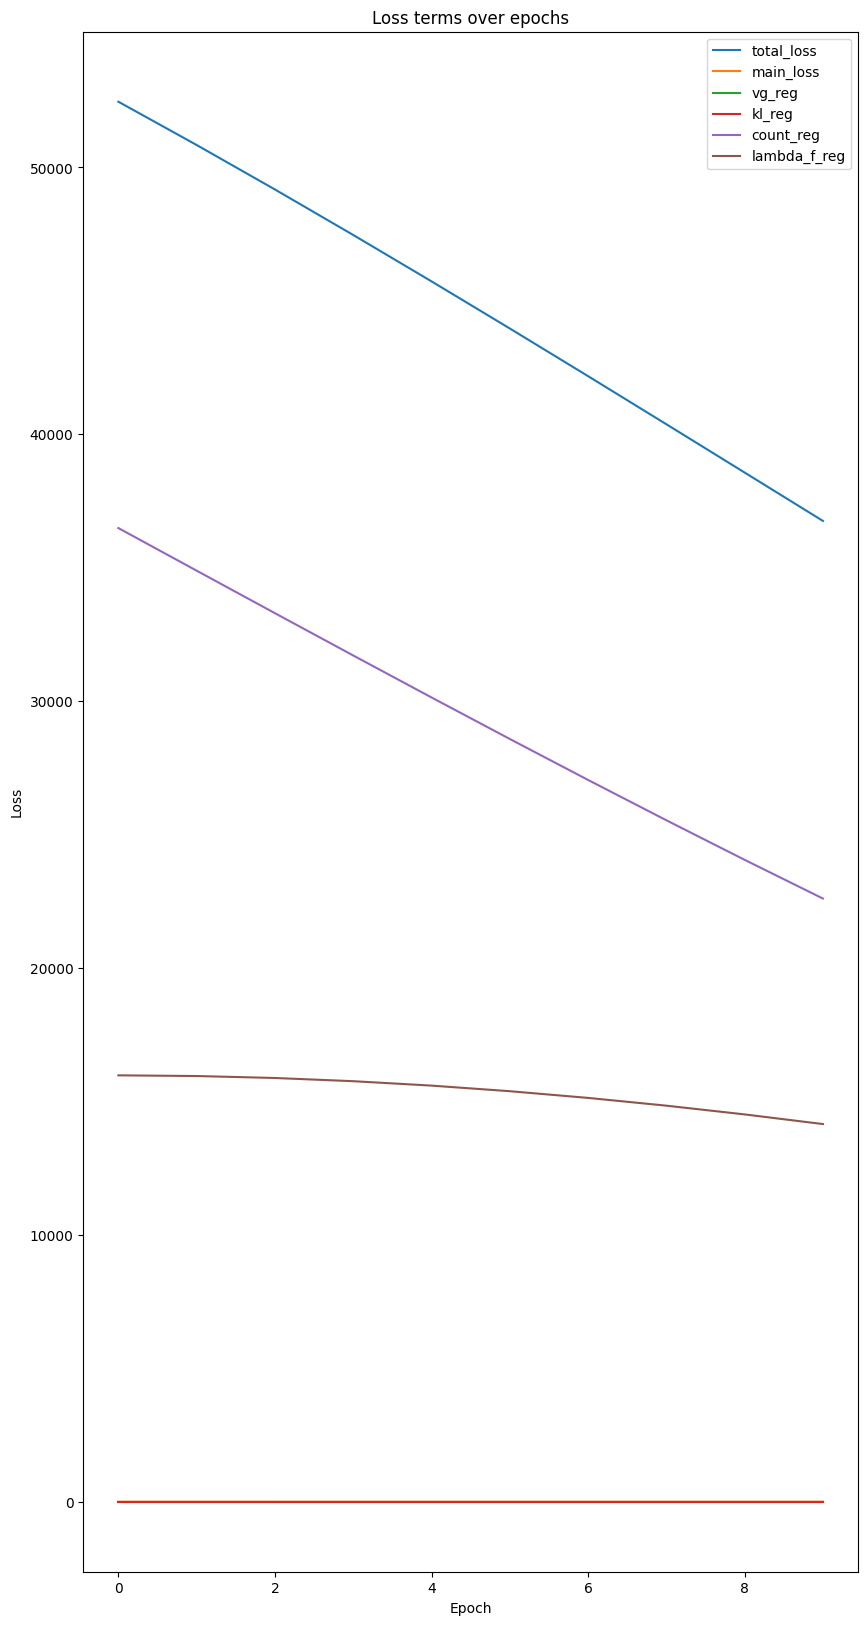

In [8]:
# Plot loss terms
for term in ad_map_baseline_filt.uns['training_history'].keys():
    value = ad_map_baseline_filt.uns['training_history'][term][0]
    print("Initial value of", term, value)
    
tgl.plot_training_history(adata_map=ad_map_baseline_filt, hyperpams=mapper_filt.hparams,
                   log_scale=False, lambda_scale=False)

Same here with very distant scales. Filter terms are on a different scales, compared to everything else.

# Model Analysis
A model with proper hyperparameters is now trained and its results analyzed.

To avoid introducing confusion, we first activate the filter mode while simultaneously deactivating the regularizers acting on the mapping matrix $M$.

We might reintroduce later the entropy regularizer to explore any possible regularazing action combined with filtering.

An important aspect to focus on is whether the final filter values are genuinly the result of alignment or they correlate to strongly with the ICs. This translates into cells that are randomly assigned to higher values at the beginning are the one getting selected during training.

## Filter Only

In [7]:
ad_map_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=300,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=0,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/300 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▏                                                                      | 1/300 [01:05<5:23:54, 65.00s/it]

Epoch 0: {'Total loss': 0.009058535099029541, 'Score': 0.5169240236282349, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


Trainig:  34%|███████████████████████▉                                               | 101/300 [27:18<34:50, 10.51s/it]

Epoch 100: {'Total loss': -0.8644298911094666, 'Score': 0.8777859807014465, 'KL divergence': 8.399365469813347e-06, 'Filter term': 4.79638671875}


Trainig:  67%|███████████████████████████████████████████████▌                       | 201/300 [44:21<17:03, 10.34s/it]

Epoch 200: {'Total loss': -0.9060691595077515, 'Score': 0.9167740345001221, 'KL divergence': 8.51624645292759e-06, 'Filter term': 0.8454590439796448}


Trainig: 100%|█████████████████████████████████████████████████████████████████████| 300/300 [1:01:13<00:00, 12.24s/it]


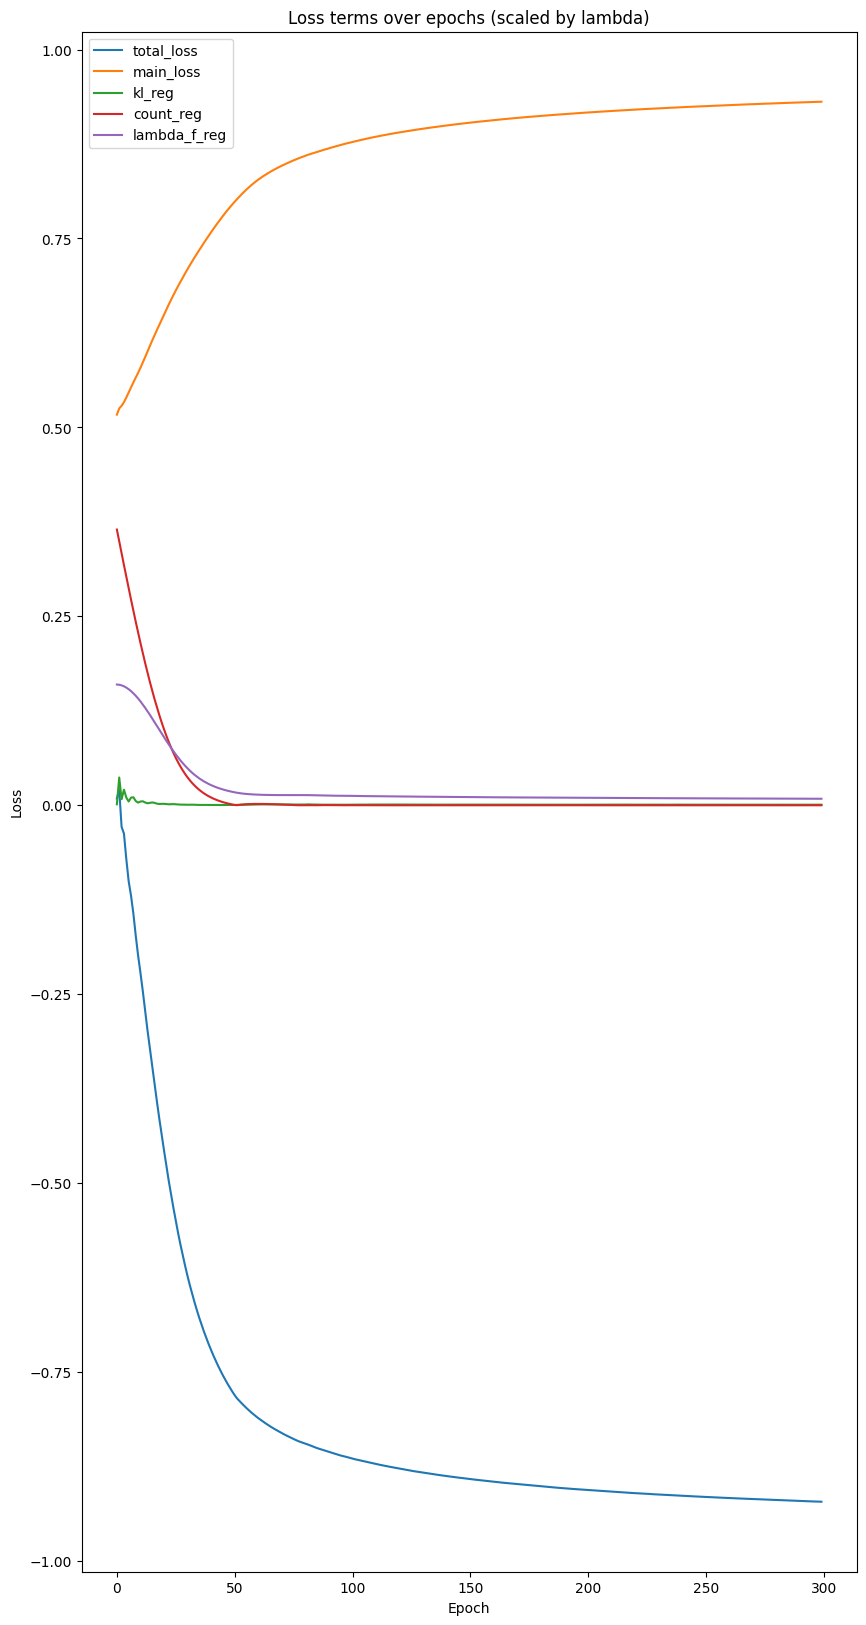

In [8]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, 
                         lambda_scale=True)

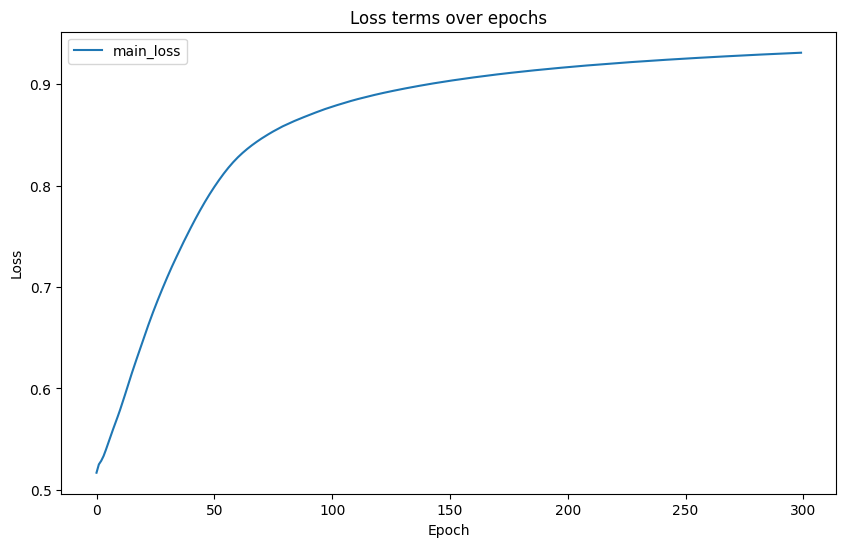

In [9]:
# Plot main loss
tgl.plot_loss_term(adata_map=ad_map_filt, loss_key="main_loss", lambda_scale=False)

The main cossim is moving towards an even higher value than with the vanilla implementation.

Loss convergence seems to be a little slower: 300 are not enough yet to plateau steadly.

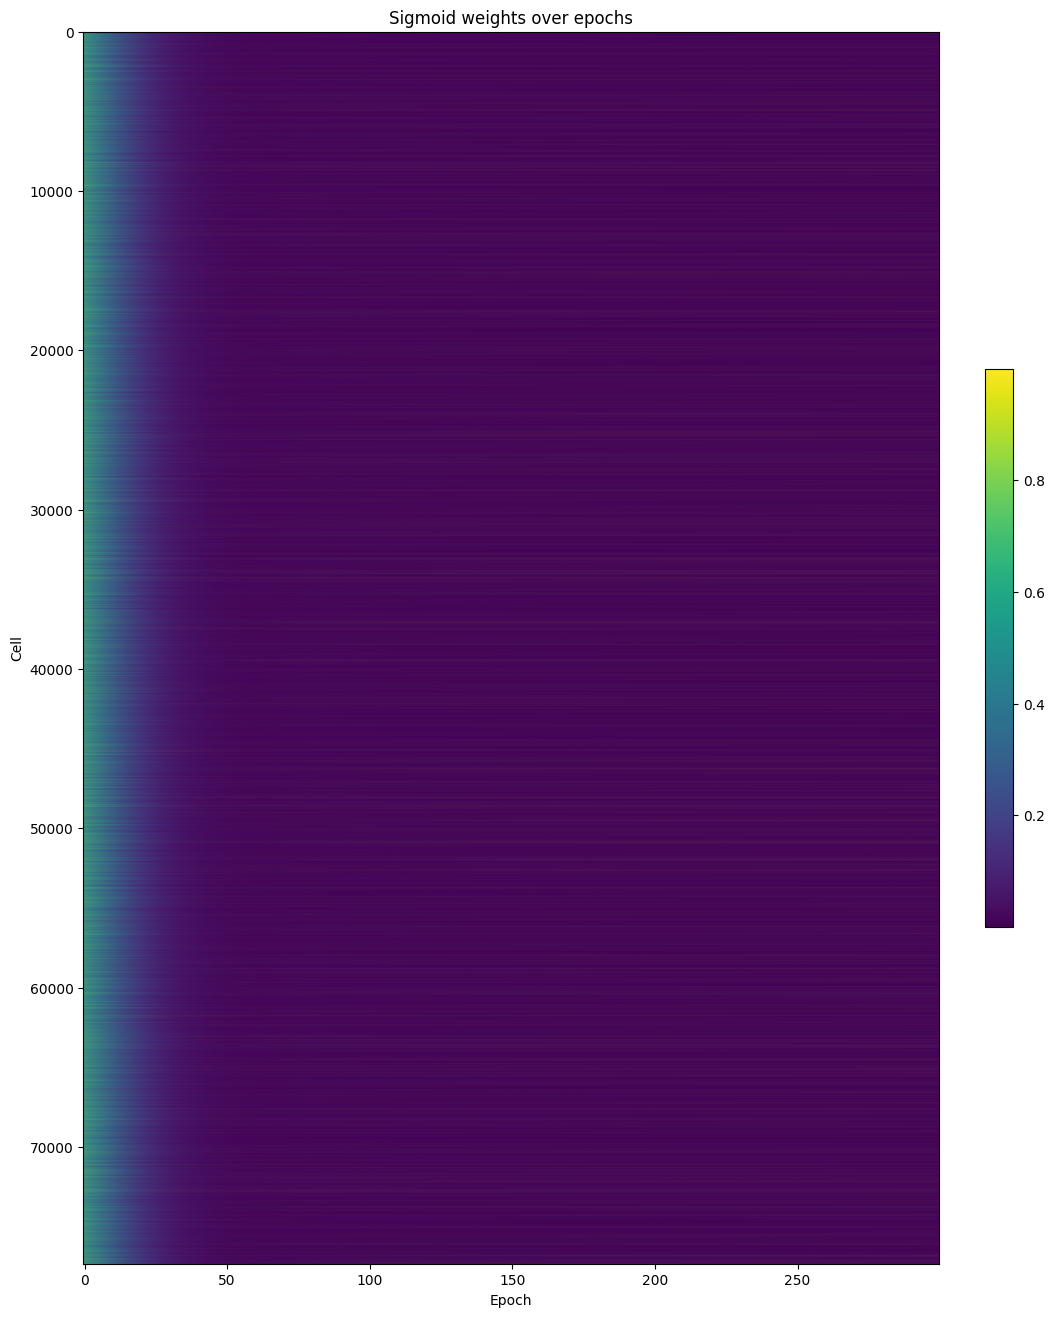

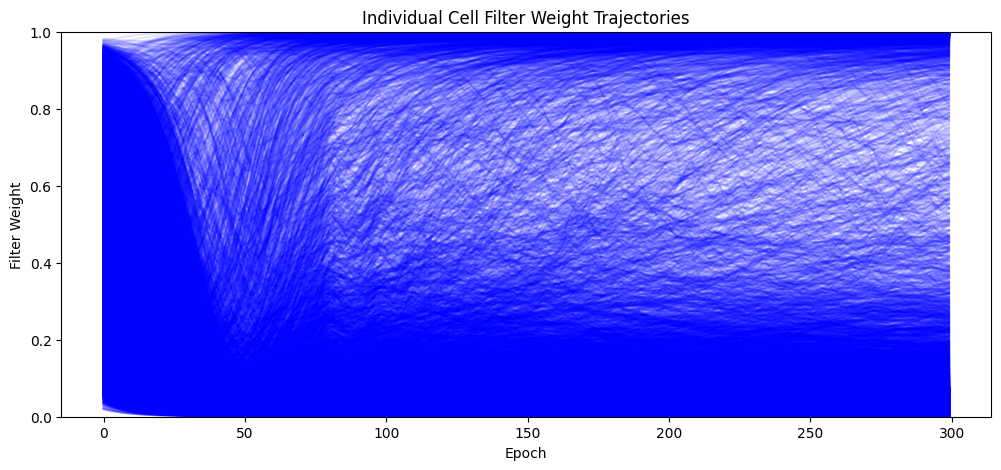

In [10]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)

Filter trajectories exhibit quite a lot of instability, but a good amount of cells are either positively or negatively selected after approximately 60-80 epochs.

Other cells remain in the gray zone for a bit, with a good amount not even converging yet. Longer trainig might show a slow but effective convergence.

In [ ]:
filt_corr = tgl.compute_filter_corr(ad_map_filt)

Final filter values don't seem to correlate much with the initial values.

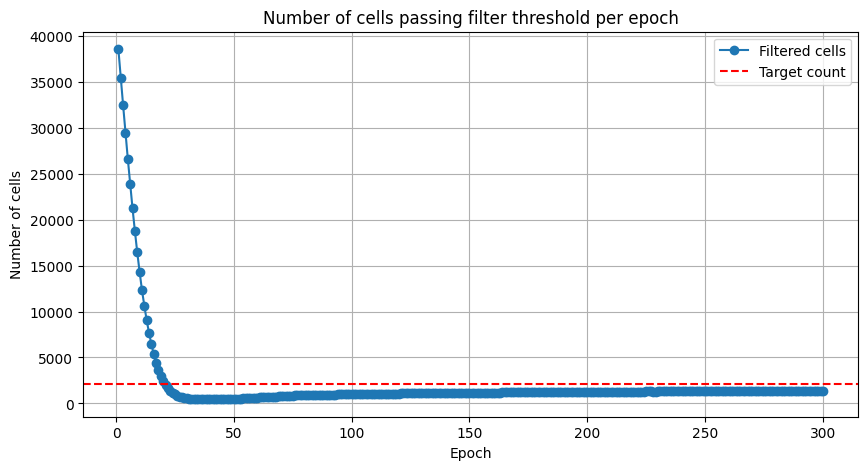

In [13]:
# Plot filter selection
tgl.plot_filter_count(ad_map_filt, target_count=None)

The number of selected cells initially drops below target but then steadily aporaches the target.

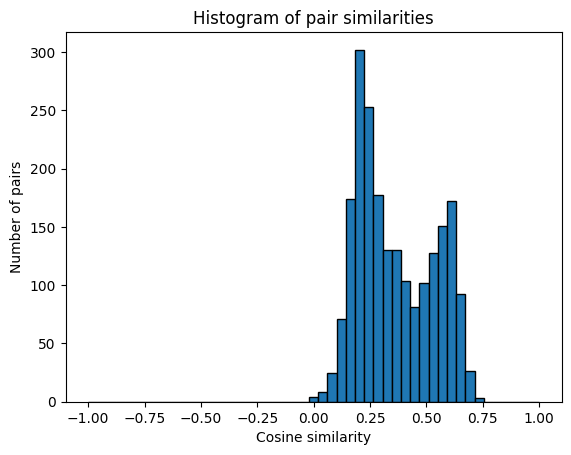

In [14]:
filt_sim = tgl.deterministic_mapping_similarity(ad_map_filt, adata_sc, adata_st, 
                                       flavour='spot_to_cell', filter=True)

The one to one deterministic similarity between selected cells and the the spot they map with the highest probability does not showcase very high values of similarity, meaning that the deterministic assignment is much less effective than general alignment.

This might be due to several factors:
* Improper convergence due to lacl of training
* Presence of multiple cells well aligning with the single spot.

In [51]:
print(adata_sc.obs.keys())
print(adata_st.obs.keys())

Index(['nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id',
       'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label',
       'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'],
      dtype='object')
Index(['sample_id', 'slice_id', 'class_label', 'subclass', 'label',
       'instance_id', 'centroid_x', 'centroid_y', 'region'],
      dtype='object')


In [15]:
true_ann, pred_ann = tgl.deterministic_annotation(
        ad_map_filt,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.subclass_label',
        st_cluster_label='subclass',
        filter=True,
)
report = tgl.annotation_report(true_ann, pred_ann)

Annotation accuracy: 0.003 %


## Regularized Model

In [16]:
# del ad_map_filt, mapper_filt, data_filt

In [17]:
ad_map_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=400,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=1e-6,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    target_count=None,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/400 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▏                                                                      | 1/400 [00:30<3:23:16, 30.57s/it]

Epoch 0: {'Total loss': 0.05066728591918945, 'Score': 0.5169240236282349, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


...

Trainig:  50%|███████████████████████████████████▋                                   | 201/400 [36:54<36:31, 11.01s/it]

Epoch 200: {'Total loss': -1.6531111001968384, 'Score': 0.8982580900192261, 'KL divergence': 8.040573447942734e-06, 'Filter term': 0.28759765625}


Trainig:  75%|█████████████████████████████████████████████████████▍                 | 301/400 [54:47<18:14, 11.06s/it]

Epoch 300: {'Total loss': -1.6691607236862183, 'Score': 0.9035118222236633, 'KL divergence': 5.704350769519806e-06, 'Filter term': 5.348876953125}


Trainig: 100%|█████████████████████████████████████████████████████████████████████| 400/400 [1:12:54<00:00, 10.94s/it]


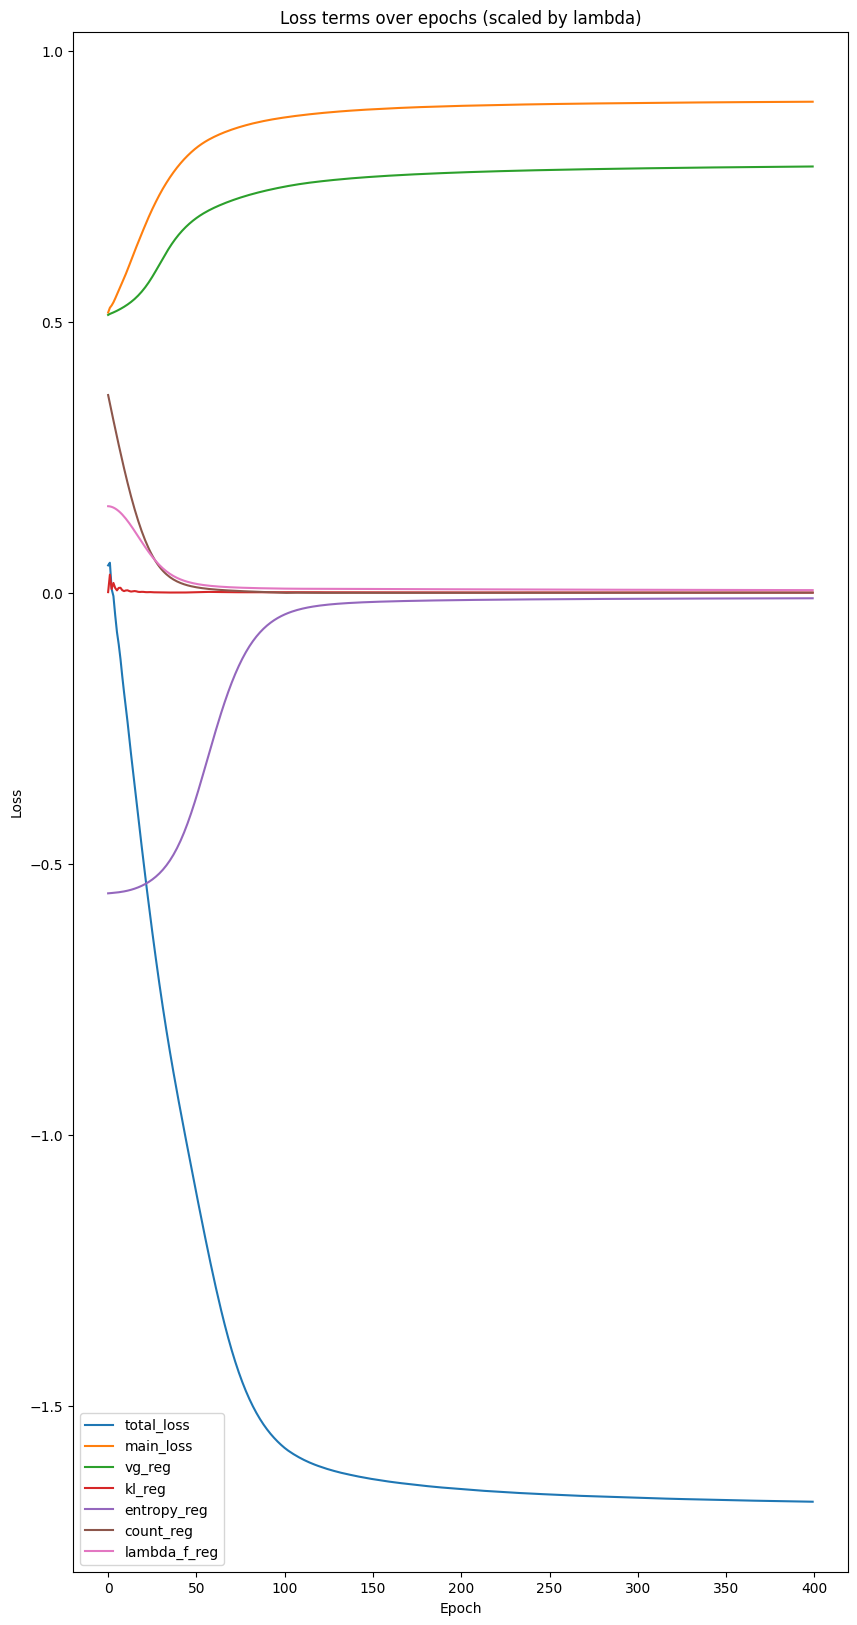

In [18]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, 
                         lambda_scale=True)

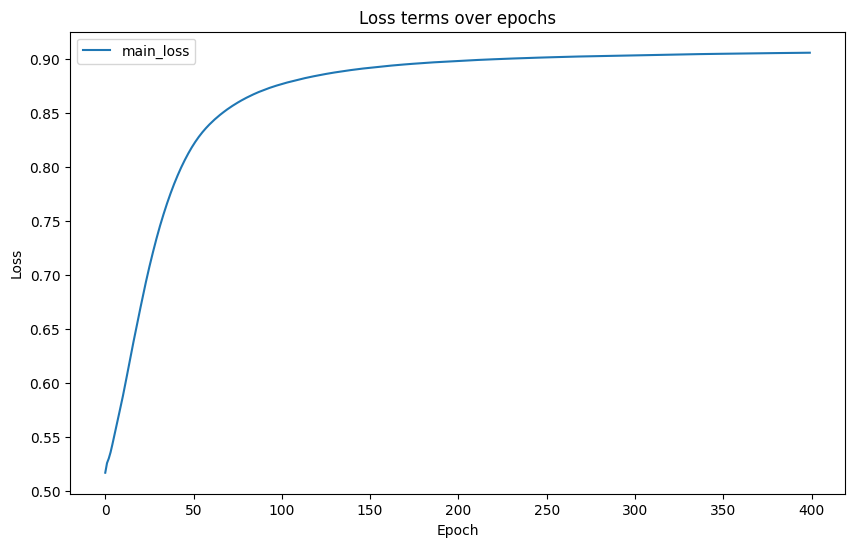

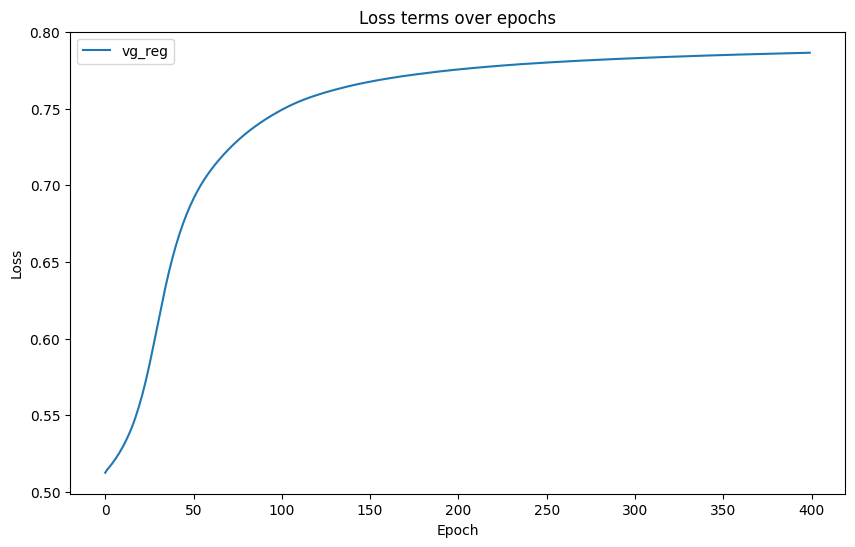

In [19]:
# Plot main loss
tgl.plot_loss_term(adata_map=ad_map_filt, loss_key="main_loss", lambda_scale=False)
# Plot voxels/genes term
tgl.plot_loss_term(adata_map=ad_map_filt, loss_key="vg_reg", lambda_scale=False)

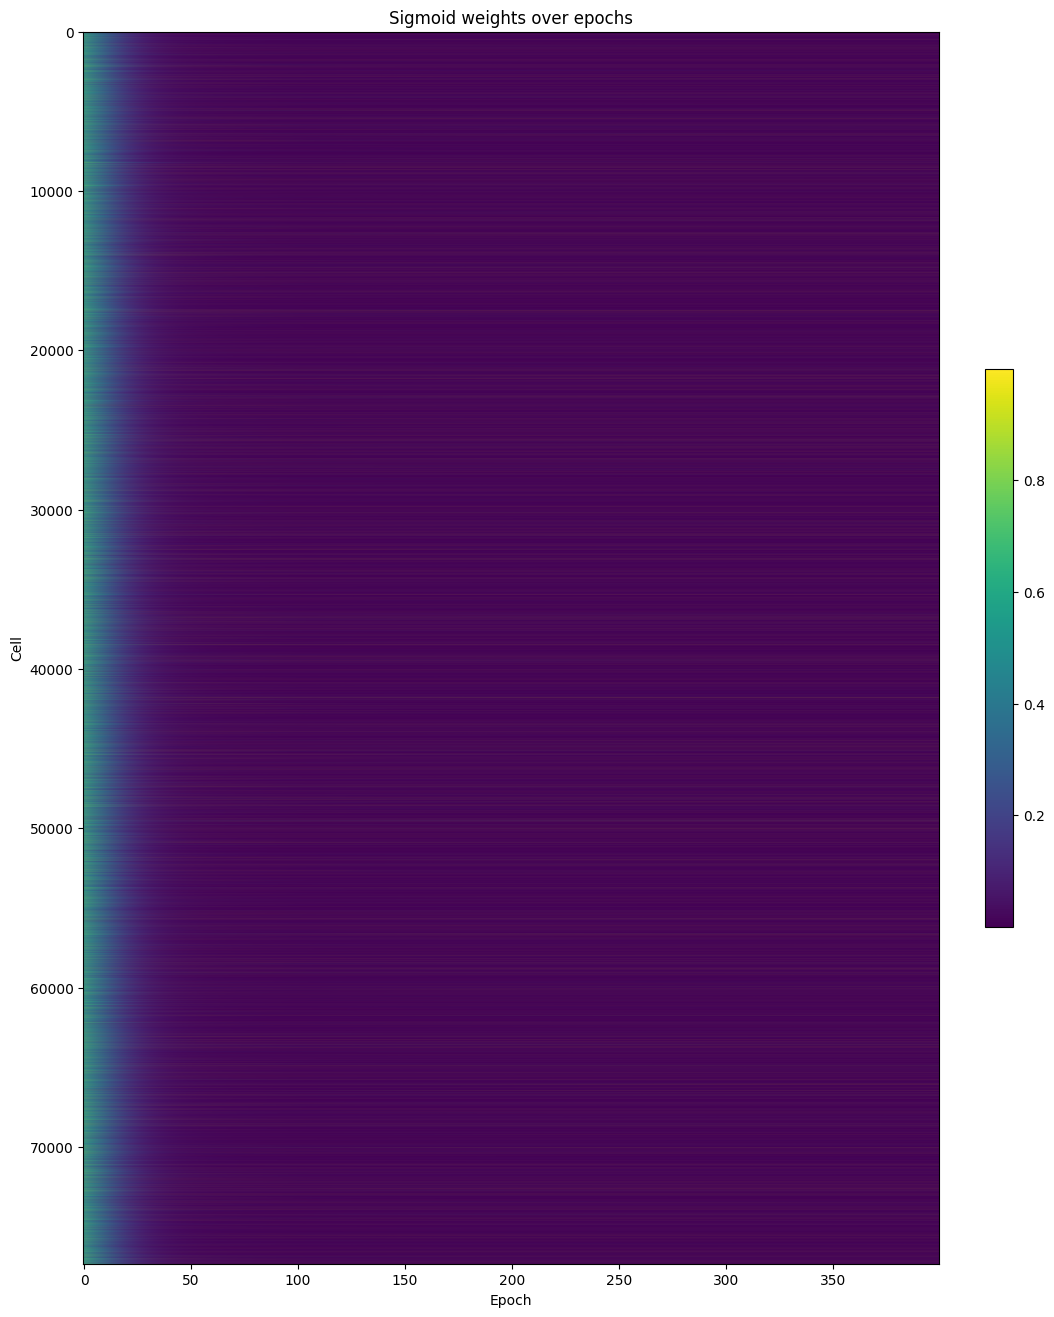

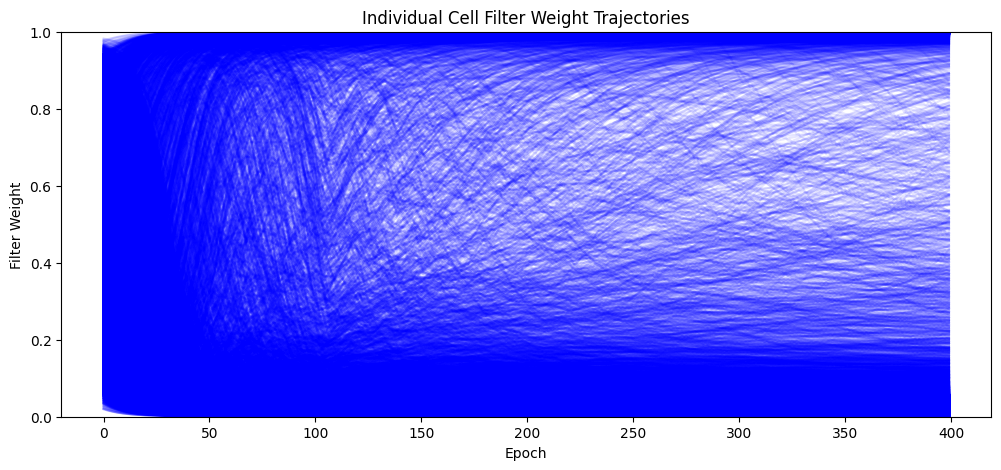

In [20]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)

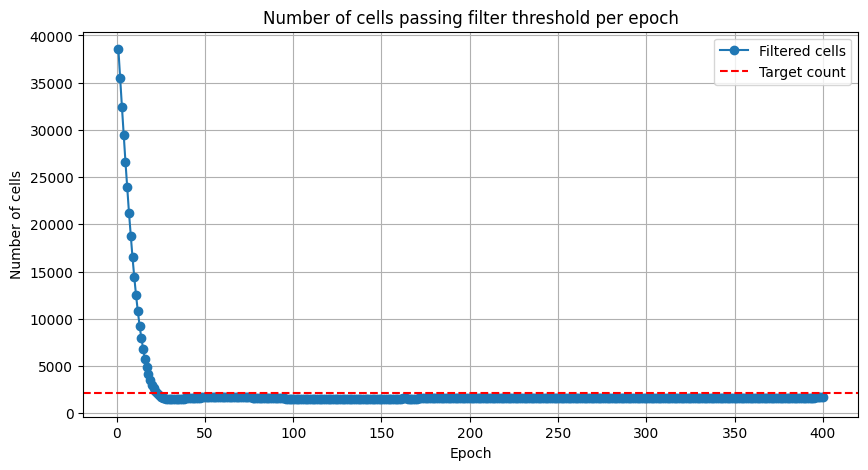

In [22]:
# Plot filter selection
tgl.plot_filter_count(ad_map_filt, target_count=None)

Pearson correlation coefficient of filter values: 0.20772307963714806


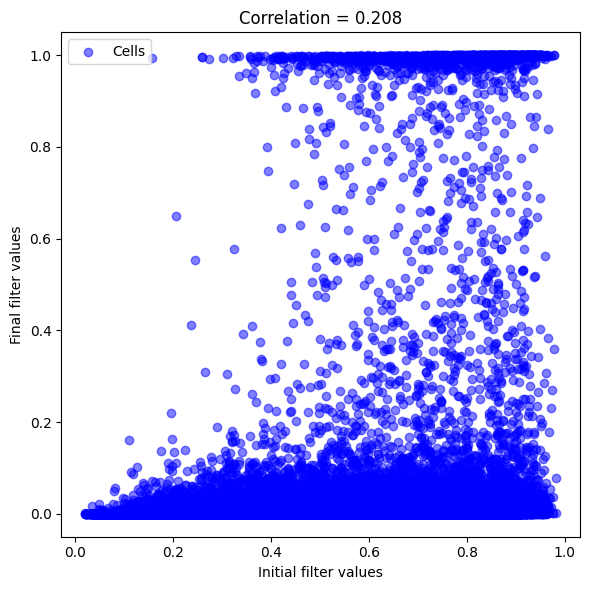

In [23]:
filt_corr = tgl.compute_filter_corr(ad_map_filt)

## Count Term
The test that follows increases the strength of the loss term penalizing shifts from the tager number of selected cells.

The filter regularizer is kept to a value comparable to other terms.

In [61]:
# del ad_map_filt, mapper_filt, data_filt

In [62]:
ad_map_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=200,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=1e-6,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1,
    lambda_f_reg=1e-4,
    target_count=None,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/200 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▎                                                                      | 1/200 [00:25<1:26:10, 25.98s/it]

Epoch 0: {'Total loss': 36487.4765625, 'Score': 0.5169240832328796, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


Trainig:  50%|███████████████████████████████████▊                                   | 101/200 [17:25<16:51, 10.21s/it]

Epoch 100: {'Total loss': 260.5618896484375, 'Score': 0.8329117298126221, 'KL divergence': 1.7480924725532532e-06, 'Filter term': 261.6243896484375}


Trainig: 100%|███████████████████████████████████████████████████████████████████████| 200/200 [33:43<00:00, 10.12s/it]


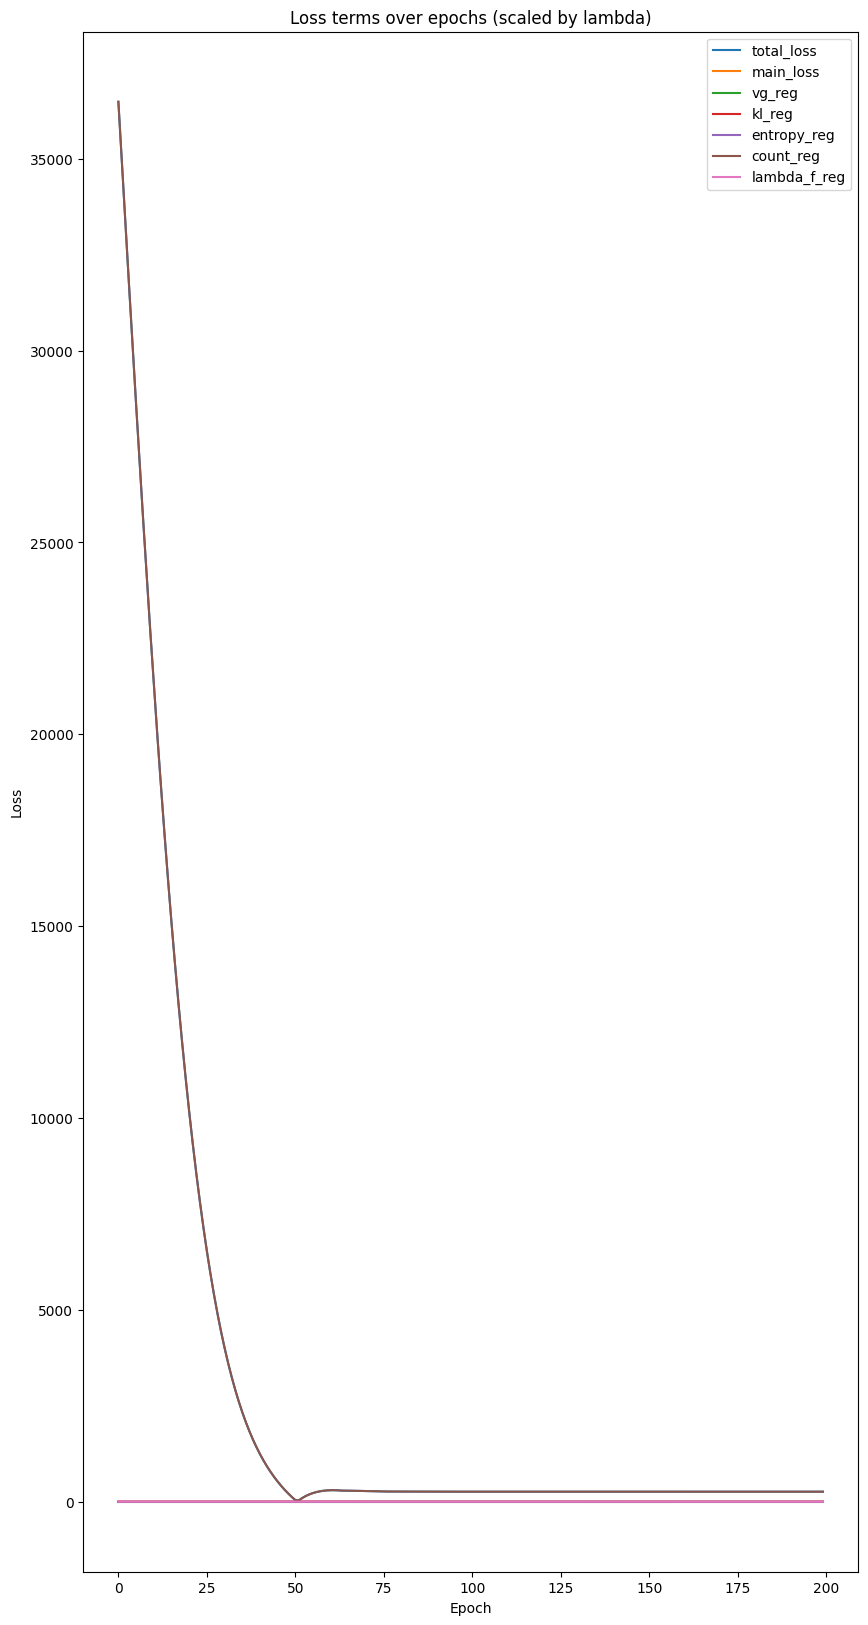

In [63]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, 
                         lambda_scale=True)

The selected term clearly dominates the loss.

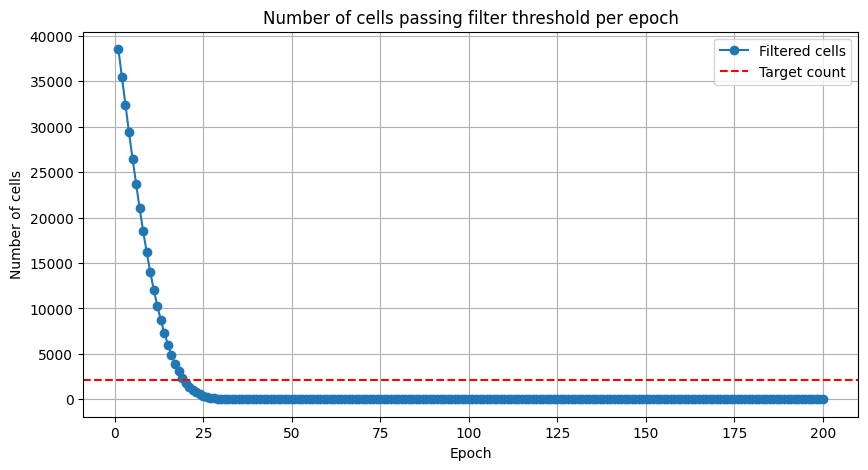

In [64]:
# Plot filter selection
tgl.plot_filter_count(ad_map_filt, target_count=None)

Contrary to what one might expect, in this scenario the number of selected cells settles to zero instead of the tagret value. The same thing is observed in the count term that touches zero at the moment of crossing the red line and then converges to a small non-zero value.

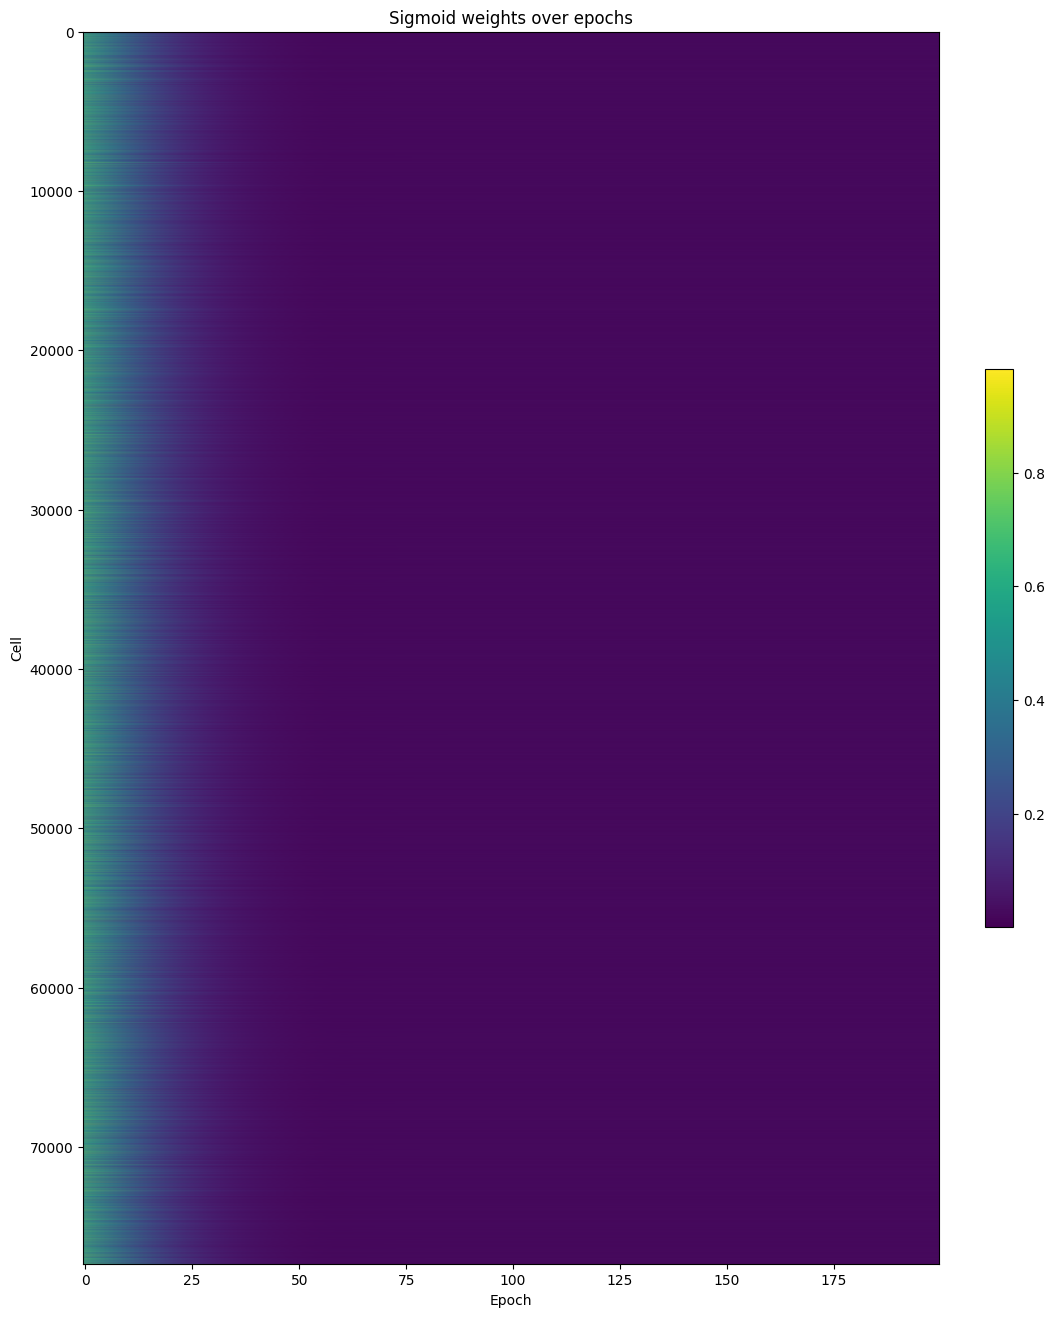

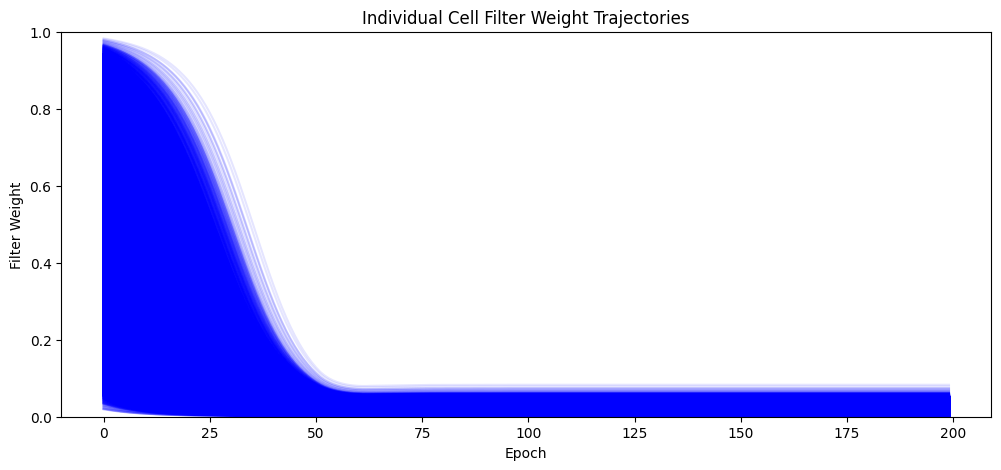

In [65]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)

Coherenlty to what is seen above, filter trajectories all converge towards zero.

This also explains the behavior above: despite being weak, the filter regularizer is still slowly bringing all cells to either side of te $[0,1]$ interval. In combination with the count term pushing most cells to zero, the whole model degenerates into excluding all cells.

Pearson correlation coefficient of filter values: 0.9973838843944649


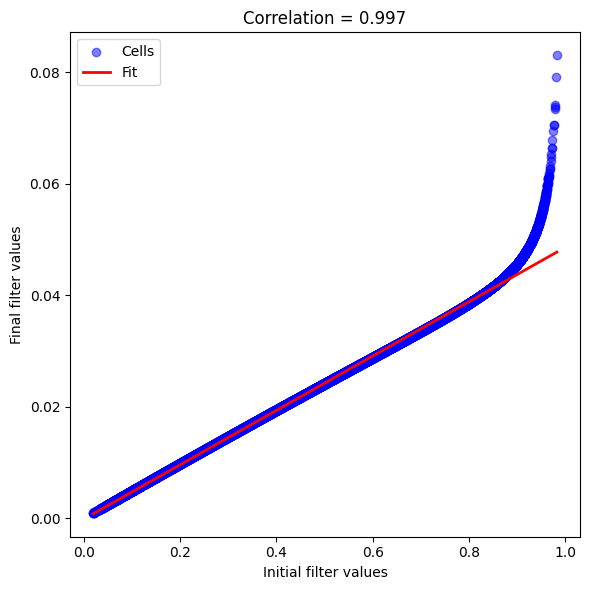

In [66]:
filt_corr = tgl.compute_filter_corr(ad_map_filt, plot_regression=True)

In this case, a strong correlation is present; the scenario remains highly undesirable.

## Filter Regularizer
In this case, we increase the strength of the filter regularizer by 3 orders of magnitude while only slightly increasing the count term weight, to evaluate its function.

In [34]:
# del ad_map_filt, mapper_filt, data_filt

In [35]:
ad_map_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=100,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-3,
    lambda_f_reg=1,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/100 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   1%|▋                                                                        | 1/100 [00:35<58:13, 35.29s/it]

Epoch 0: {'Total loss': 16013.4755859375, 'Score': 0.5169240832328796, 'KL divergence': 1.3388926163315773e-05, 'Filter term': 36486.3515625}


Trainig: 100%|███████████████████████████████████████████████████████████████████████| 100/100 [15:57<00:00,  9.57s/it]


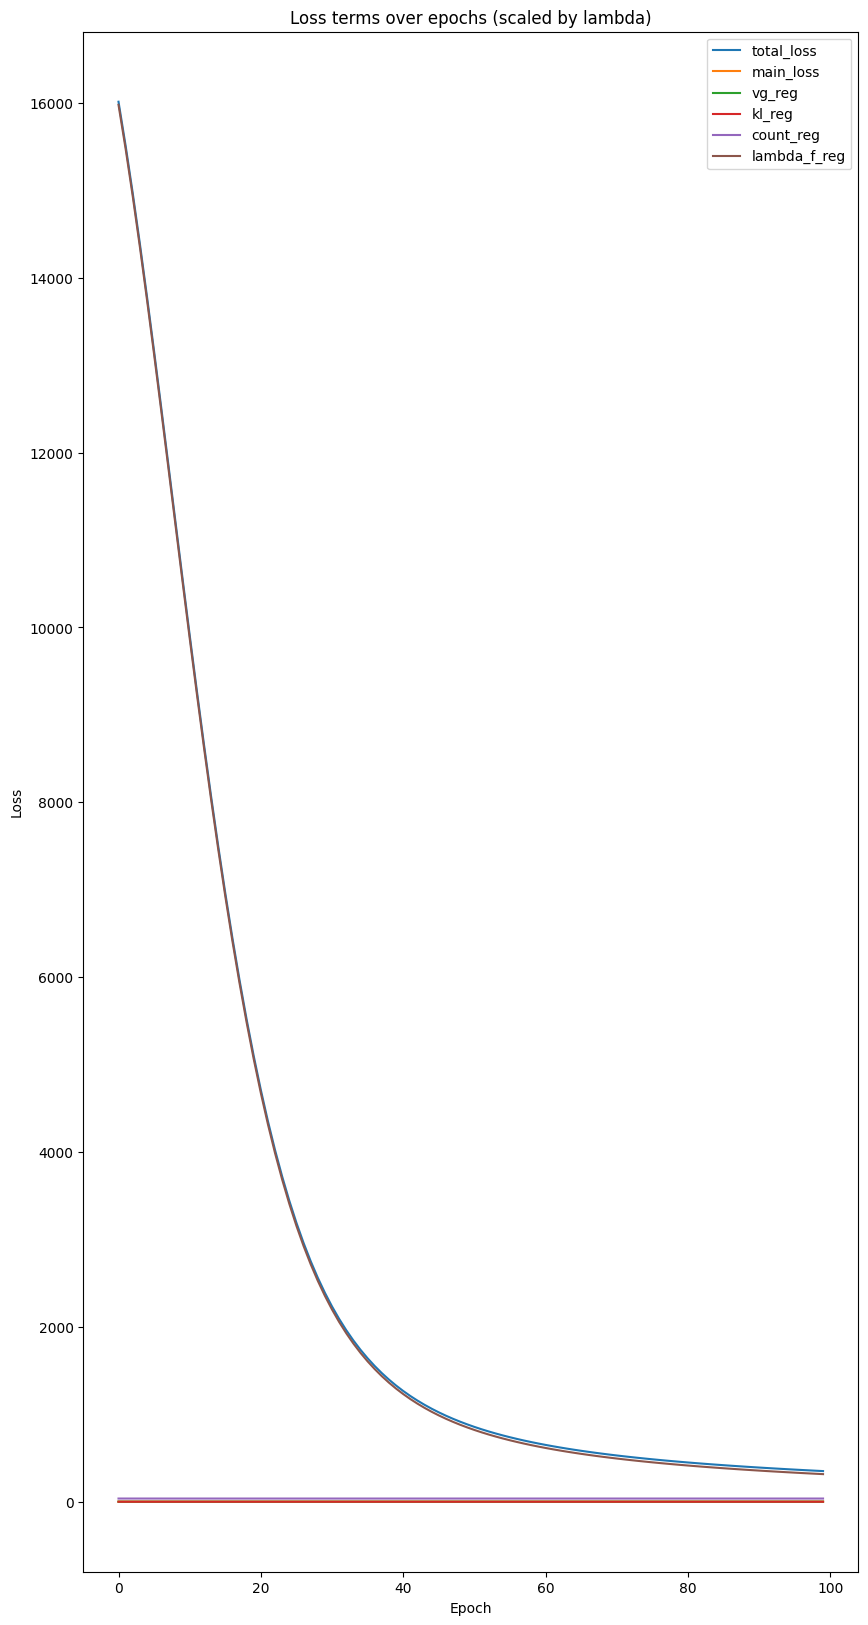

In [36]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, 
                         lambda_scale=True)

We immediately notice the filter regularizer dominating the loss.

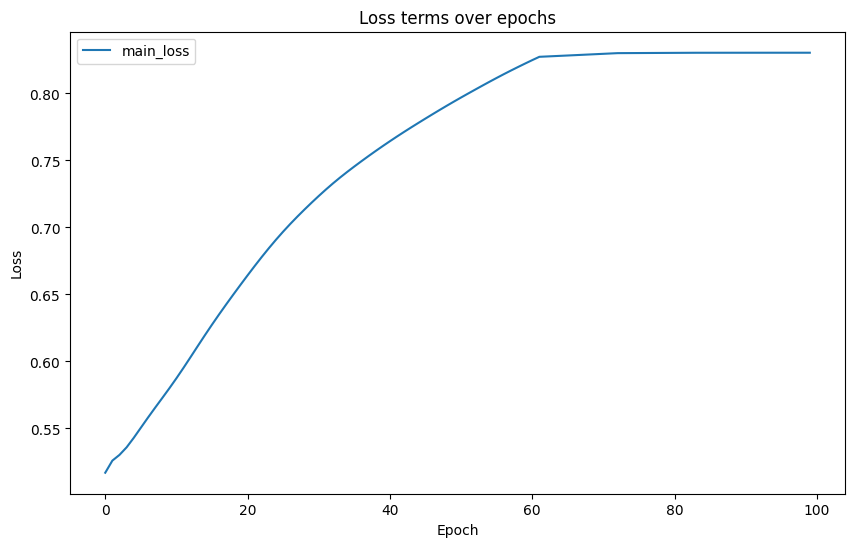

In [31]:
# Plot main loss
tgl.plot_loss_term(adata_map=ad_map_filt, loss_key="main_loss", lambda_scale=False)

The main loss convergence is still satisfactory.

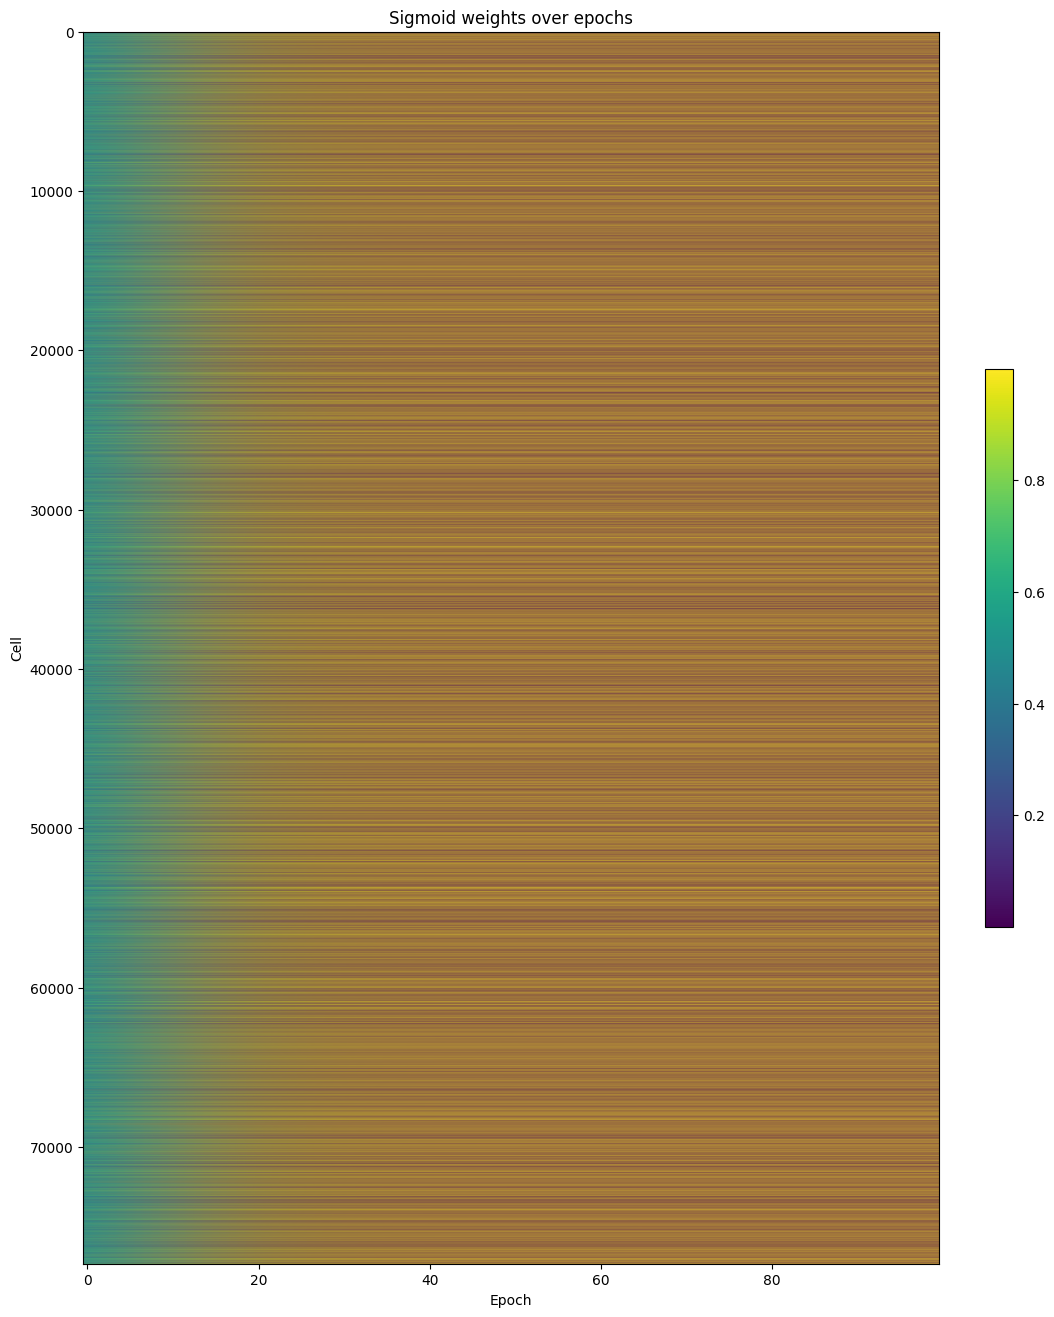

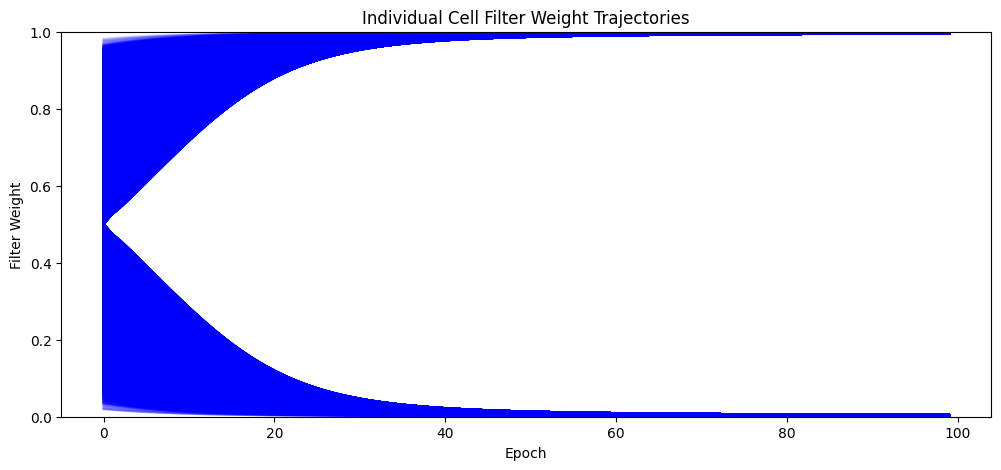

In [40]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)

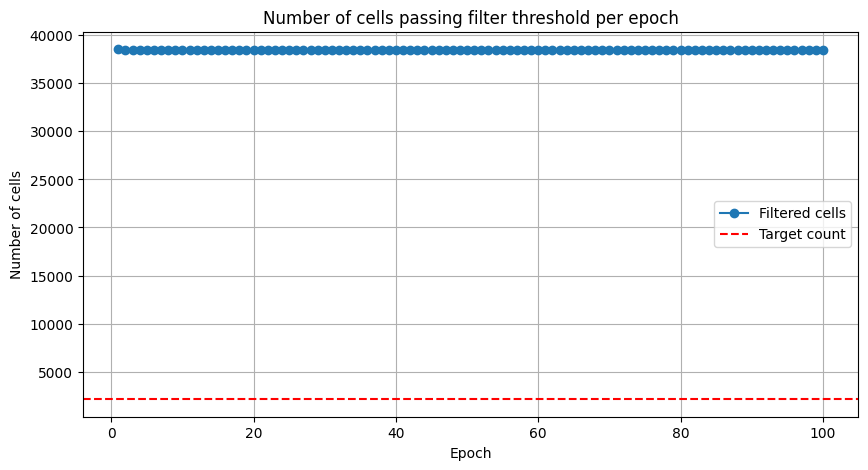

In [37]:
tgl.plot_filter_count(ad_map_filt, target_count=None)

In [38]:
# Check
print(f"Target count: {mapper_filt.hparams['target_count']}")
print(f"Selected cells over epochs: {ad_map_filt.uns['filter_history']['n_cells']}")

#N selcted cells over epochs: [38541, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490, 38490]
Target count: 2133


Pearson correlation coefficient of filter values: 0.8394521070468609


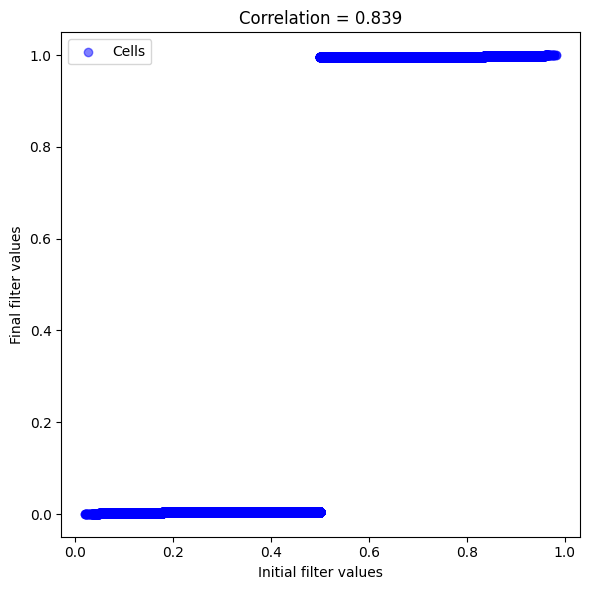

In [39]:
filt_corr = tgl.compute_filter_corr(ad_map_filt)

The plots above clearly show the effect of a super strong regularization:
* the initial filter values are distributed normally with a Standard distribution (zero centered)
* when going through a sigmoid activation the values reshape into a logit-normal distribution which is centered around 0.5 and in case of $\sigma = 1$ in the input Normal, has overall weight towards the center
* the filter regularizer immediately splits the filter entries based on the IC into values over and under 0.5 (the same regularizer loss is a sad parabola centered in 0.5)
* these values quickly converge towards the extremes
* the target count is disregarded and the filter settles on a number of selcted cells equal to the starting total.

## Conclusions
The last two experiments showcase the limit cases of filter implementation. The main insight we can get is that putting to much weight into these terms might produce unwanted behaviours, that are also not entirely expected.

Addition of vanilla regularizer terms does not seem to improve training in a significant way.

# Uniform Distribution
We now test a model that initializes all filter values in a uniform distribution to $\frac{1}{n_{spots}}$.

This is different from sampling a **Unifrom Distribution** and then applying a sigmoid activation and is rather a way to initalize all values according to a pre-determined distribution that does not introduce any bias towards random cells.

In [8]:
ad_map_unif, mapper_unif, data_unif = tgl.map_cells_to_space(
    adata_sc, 
    adata_st, 
    mode='filter',
    learning_rate=0.1,
    num_epochs=400,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=1e-6,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    target_count=None,
    random_state=42,
    )

in


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/400 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▏                                                                      | 1/400 [01:01<6:47:00, 61.20s/it]

Epoch 0: {'Total loss': 0.08447951078414917, 'Score': 0.5169236063957214, 'KL divergence': 1.1876923963427544e-05, 'Filter term': 36535.75390625}


...

Trainig:  50%|███████████████████████████████████▋                                   | 201/400 [34:50<32:54,  9.92s/it]

Epoch 200: {'Total loss': -0.3294271230697632, 'Score': 0.6134878396987915, 'KL divergence': 4.429370164871216e-06, 'Filter term': 14276.3779296875}


Trainig:  75%|█████████████████████████████████████████████████████▍                 | 301/400 [51:05<14:23,  8.73s/it]

Epoch 300: {'Total loss': -0.32942724227905273, 'Score': 0.6134878396987915, 'KL divergence': 4.428671672940254e-06, 'Filter term': 14276.3779296875}


Trainig: 100%|█████████████████████████████████████████████████████████████████████| 400/400 [1:06:21<00:00,  9.95s/it]


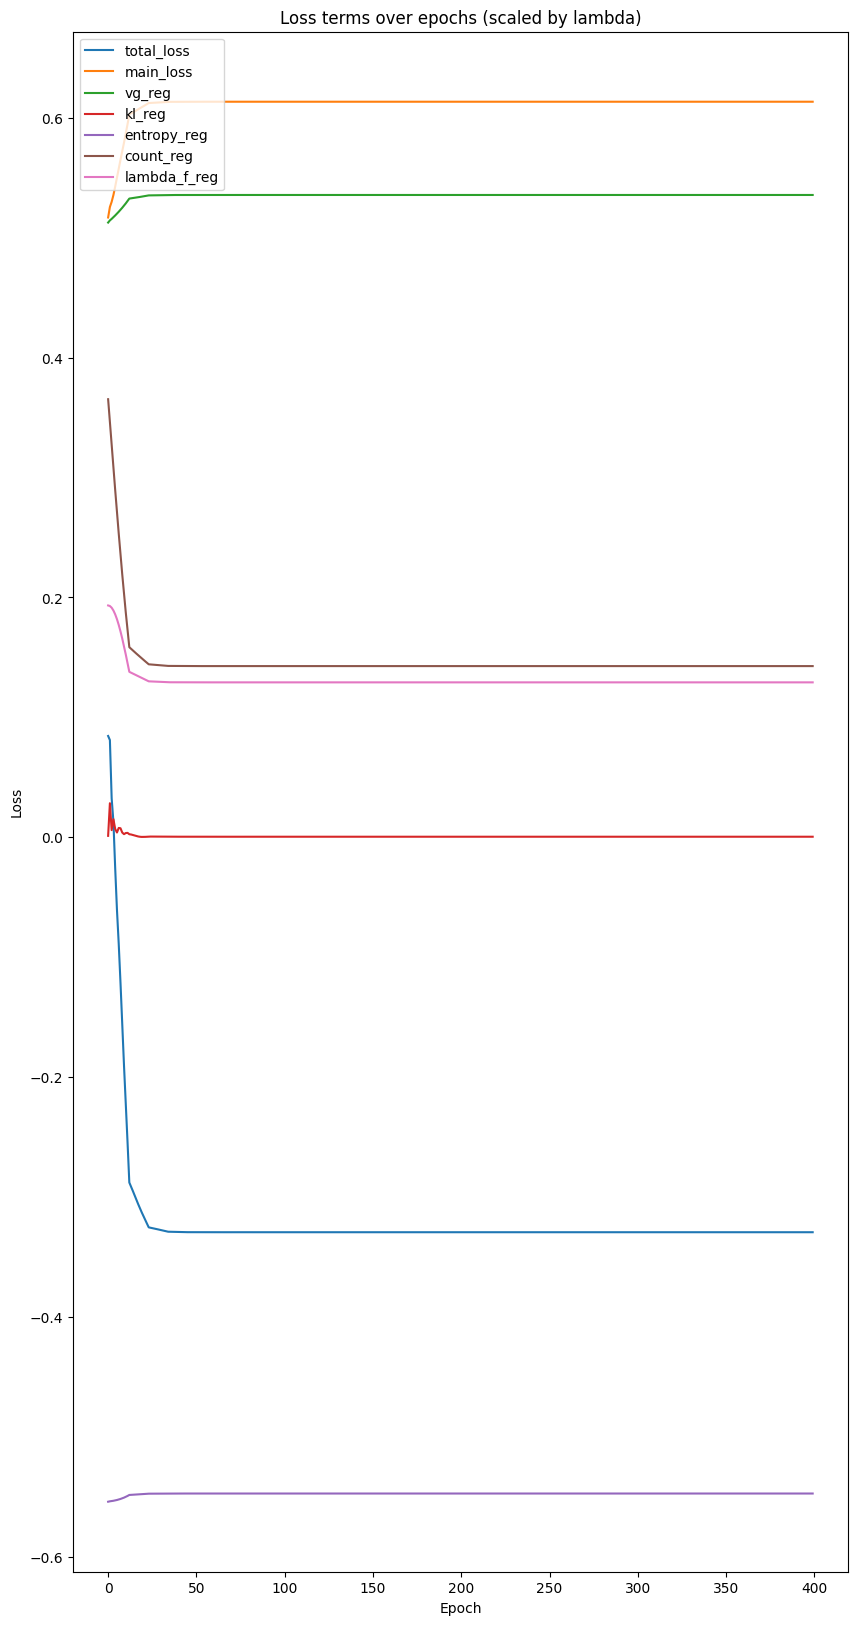

In [10]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_unif, hyperpams=mapper_unif.hparams, 
                         lambda_scale=True)

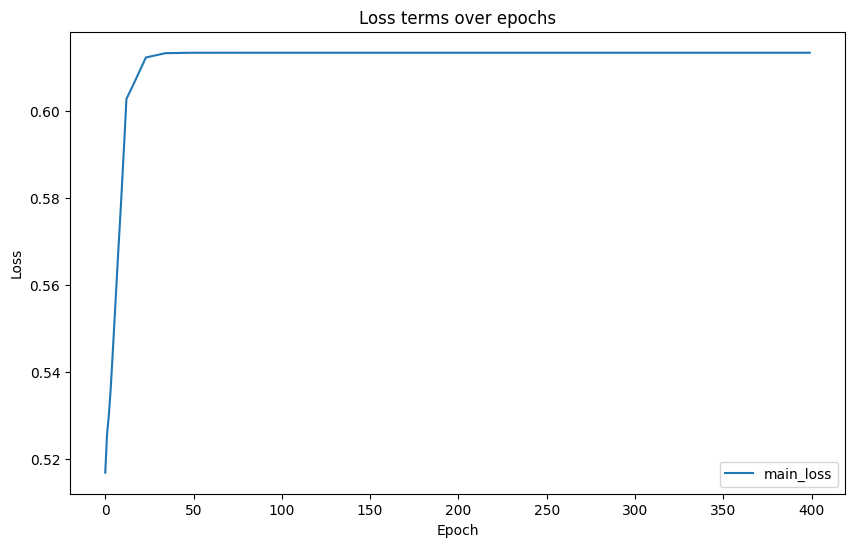

In [12]:
# Plot main loss
tgl.plot_loss_term(adata_map=ad_map_unif, loss_key="main_loss", lambda_scale=False)

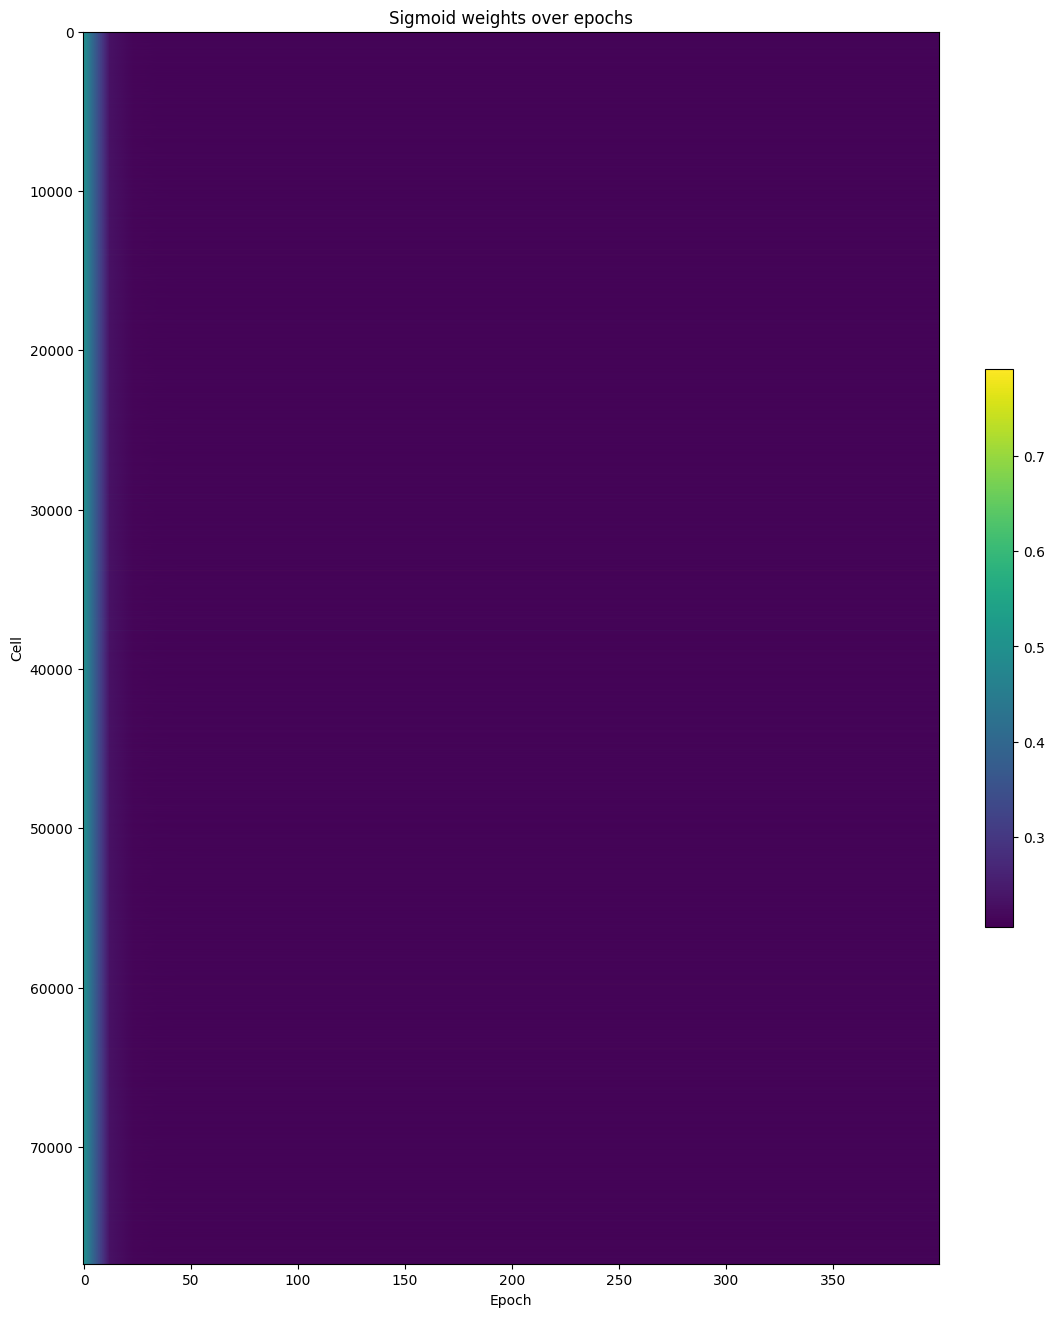

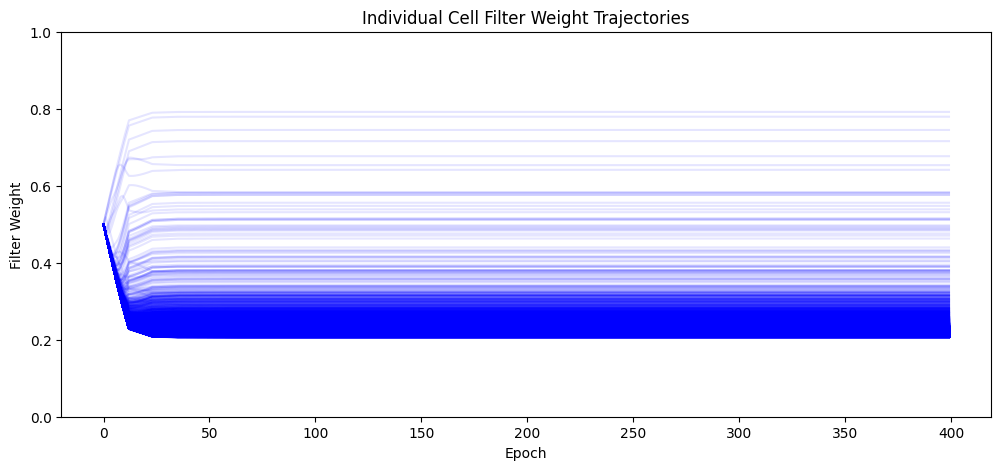

In [13]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_unif, plot_spaghetti=True, plot_envelope=False)

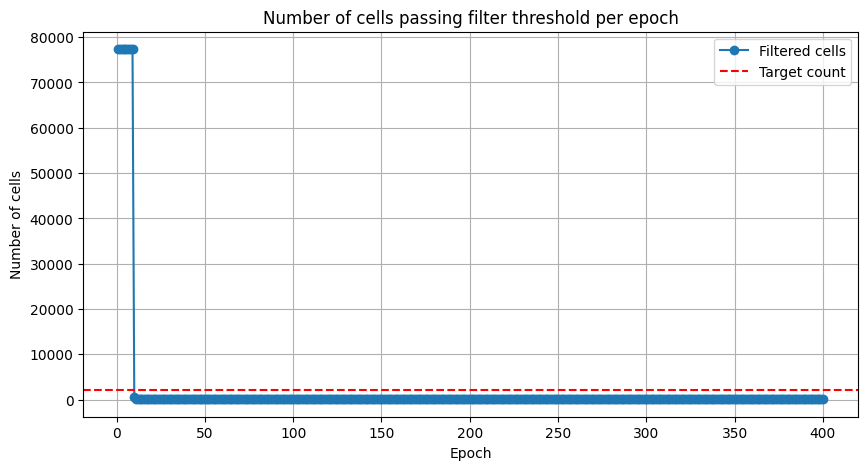

In [19]:
# Plot filter selection
tgl.plot_filter_count(ad_map_unif, target_count=None, threshold=0.3)

Results show good convergence but poor performance overall. Additionally, the filter does not learn any significant subset of cells and does not settle towards the extremes remaining in the middle band fro $0.2$ to $0.8$, with most cells falling in the grey zone aroind $0.3$.

This testifies that a little amount of bias, introduced at the beginning with random sampling, allows the model to learn filtering much better.

This, instead, opens the way to experimenting with diferent initial distributions:
* A Normal distributions maps into a Logit-Normal, thus playing with the variance allows to move the activated values weight more or less on the center (more U shaped). A Standard distribution provides a Logit-Normal well centerd around 0, which might be the best choice as it sets most cells in the middle.
* A Uniform distribution gest pushed into a U shaped version by the sigmoid activation: playing with the support allows to modulate the weight similarly as above.

# No Cell Selection
Here we train the model in filter mode with SC data that did not undergo cell selection, which includes removal of low quality cells and label harmonization.

In [3]:
adata_sc = sc.read_h5ad("H:/Il mio Drive/data_tangram/counts100k_norm_wo_raw_train_genes.h5ad") # log1p
adata_sc

AnnData object with n_obs × n_vars = 100000 × 253
    obs: 'nUMI', 'nGene', 'dataset', 'QC', 'cluster', 'Allen.cluster_id', 'Allen.cluster_label', 'Allen.cluster_color', 'Allen.class_label', 'Allen.subclass_label', 'comb.QC', 'train_set', 'test_set'
    var: 'gene_ids', 'feature_types', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'Allen.class_label_colors', 'Allen.cluster_color_colors', 'Allen.cluster_label_colors', 'Allen.subclass_label_colors', 'cluster_colors', 'hvg', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [14]:
adata_sc.uns['hvg']  # requires log1p

{'flavor': 'seurat_v3'}

In [4]:
adata_st = sc.read_h5ad("H:/Il mio Drive/data_tangram/slice200_pp.h5ad")
adata_st

AnnData object with n_obs × n_vars = 2133 × 254
    obs: 'sample_id', 'slice_id', 'class_label', 'subclass', 'label', 'instance_id', 'centroid_x', 'centroid_y', 'region'
    var: 'is_sequential', 'is_combinatorial', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'sparsity'
    uns: 'gearyC', 'hvg', 'log1p', 'moranI', 'spatial_neighbors', 'spatialdata_attrs', 'training_genes'
    obsm: 'spatial'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [5]:
ad_map_filt, mapper_filt, data_filt = tgl.map_cells_to_space(
    adata_sc=adata_sc, 
    adata_st=adata_st, 
    mode='filter',
    num_epochs=300,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=0,
    lambda_r=0,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    random_state=42,
    )

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


in



  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 213 M  | n/a  
---------------------------------------------------------
213 M     Trainable params
0         Non-trainable params
213 M     Total params
853.600   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode
Trainig:   0%|                                                                                 | 0/300 [00:00<?, ?it/s]

Training with 252 genes
S matrix shape: torch.Size([100000, 252])
G matrix shape: torch.Size([2133, 252])


Trainig:   0%|▏                                                                      | 1/300 [00:49<4:07:42, 49.71s/it]

...

Trainig:  34%|██████████████████████▌                                            | 101/300 [1:33:32<3:04:44, 55.70s/it]

Epoch 100: {'Total loss': -0.21992534399032593, 'Score': 0.6087257266044617, 'KL divergence': 4.1185412555933e-06, 'Filter term': 22856.70703125}


Trainig:  67%|████████████████████████████████████████████▉                      | 201/300 [3:04:12<1:23:40, 50.71s/it]

Epoch 200: {'Total loss': -0.21992415189743042, 'Score': 0.6087257862091064, 'KL divergence': 4.131346940994263e-06, 'Filter term': 22856.705078125}


Trainig: 100%|█████████████████████████████████████████████████████████████████████| 300/300 [4:32:38<00:00, 54.53s/it]


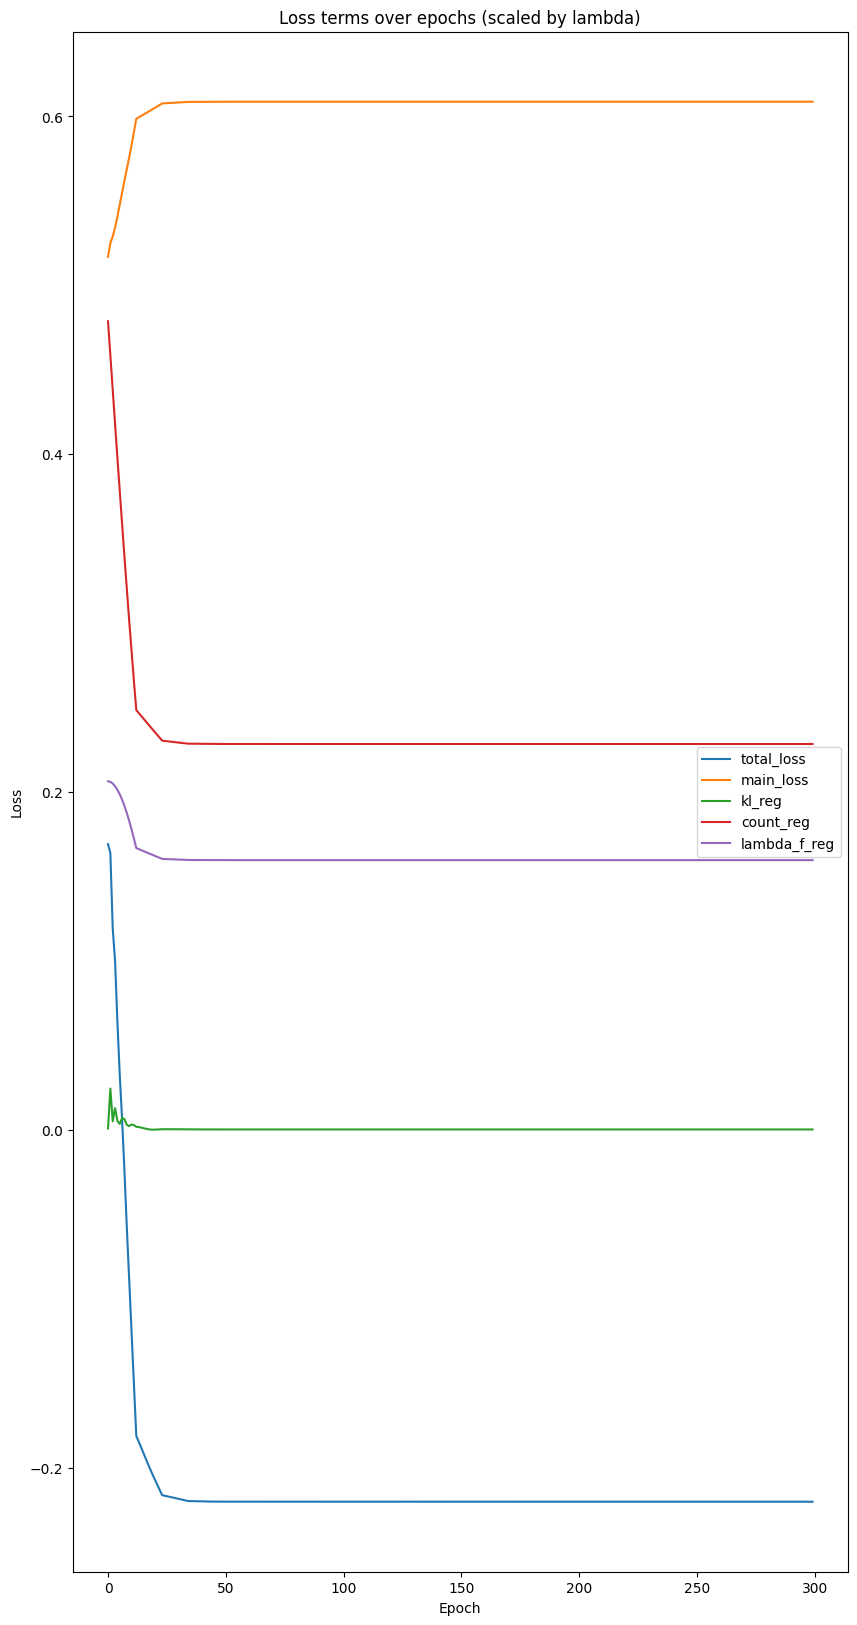

In [6]:
# Plot loss terms
tgl.plot_training_history(adata_map=ad_map_filt, hyperpams=mapper_filt.hparams, 
                         lambda_scale=True)

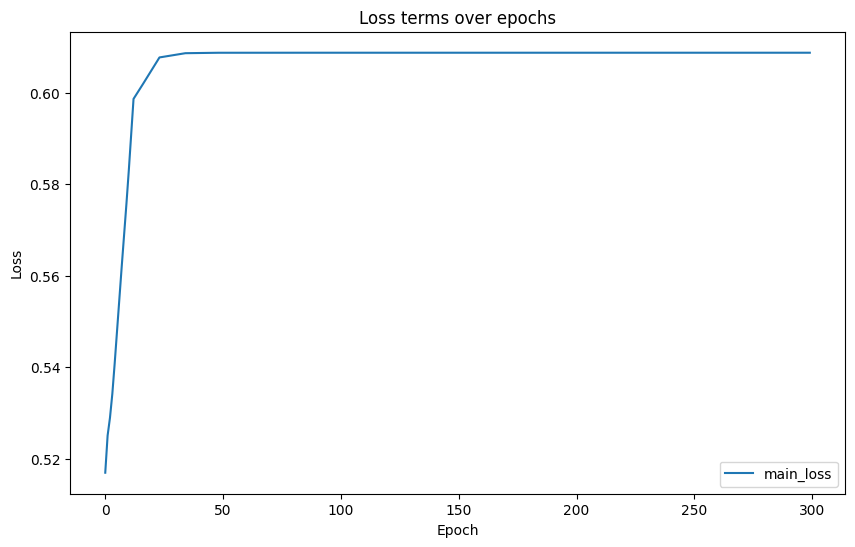

In [15]:
# Plot main loss
tgl.plot_loss_term(adata_map=ad_map_filt, loss_key="main_loss", lambda_scale=False)

The loss landscape appears to be less smooth than usual and the score converges to a sub-optimal value, showing little learning.

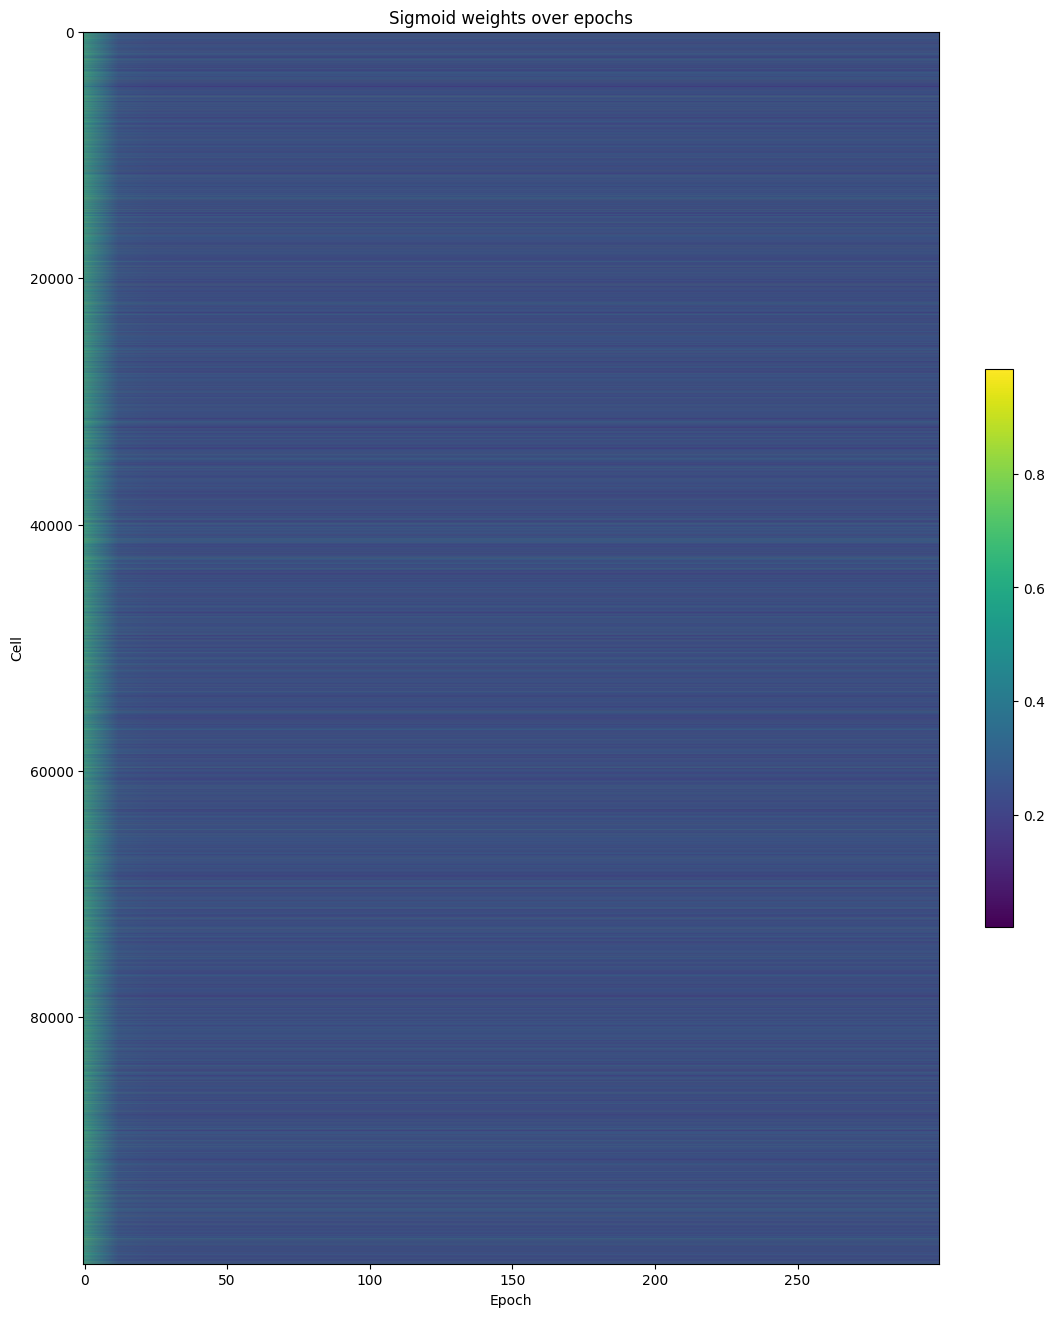

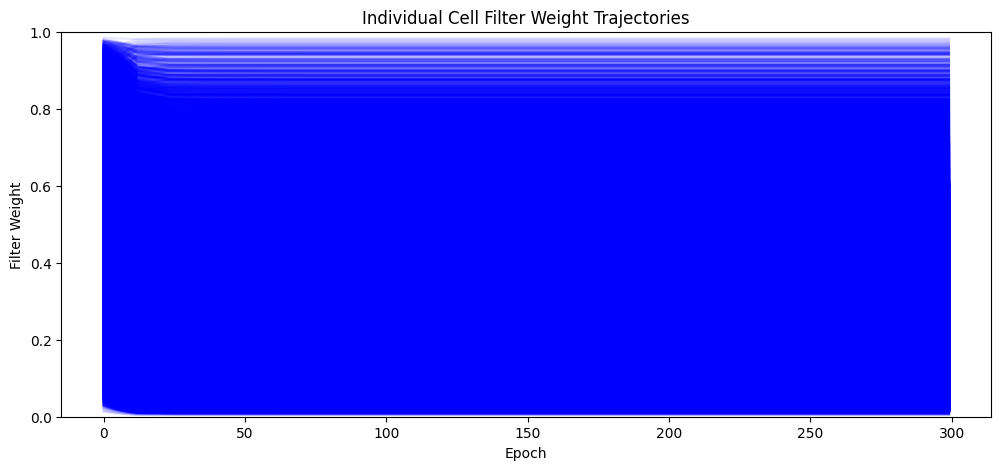

In [7]:
# Plot final filter values distribution
tgl.plot_filter_weights(ad_map_filt, plot_spaghetti=True, plot_envelope=False)

Filter entries do not converge to the edges with the same weighting of the previous experiments, meaning that the model struggles to identify the best alignned cells.

A heavier weight and longer trainig could perhaps improve performance a bit.

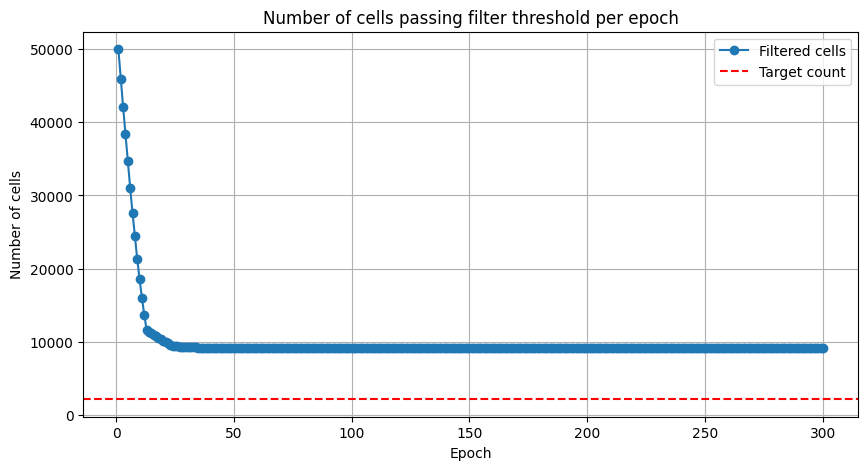

In [9]:
# Plot filter selection
tgl.plot_filter_count(ad_map_filt, target_count=None)

Even for what regards the target count, the model stabilizes towards another value with a very significant offset. It looks like the filter is not learning at all so there is a stable fraction of cells that surpass the threshold, that are not truly representative of the spatial data.

In [34]:
# At execution time, the functionrun had issues handling anndata indexes.
# A monkey patch is executed and then pulled to source code.

from tangramlit.mapping_analysis import *

def compute_mapped_similarity_local(adata_map, adata_sc, adata_st, flavour: str, 
                                    filter=False, threshold=0.5, plot=True):

    # Make all gene names to lower case
    adata_sc.var_names = adata_sc.var_names.str.lower()
    adata_st.var_names = adata_st.var_names.str.lower()

    # Get deterministic cell-spot pair, always (spot_idx, cell_idx)
    if flavour == "spot_to_cell":
        # Each spot assigned to a cell
        pairs_df = get_spot_cell_pair(adata_map, filter=filter, threshold=threshold)
    elif flavour == "cell_to_spot":
        # Each cell assigned to a spot
        pairs_df = get_cell_spot_pair(adata_map, filter=filter, threshold=threshold)
    else:
        raise ValueError("Invalid flavour. Choose either 'spot_to_cell' or 'cell_to_spot'.")

    # Get shared genes
    shared_genes = adata_map.uns['training_genes']
    
    # Extract expression profiles
    sc_profile = adata_sc[pairs_df['cell index'].to_numpy(), shared_genes].X
    st_profile = adata_st[pairs_df['spot index'].to_numpy(), shared_genes].X
    
    # Explicitly densify sparse matrices
    if hasattr(sc_profile, "toarray"):
        sc_profile = sc_profile.toarray()
    if hasattr(st_profile, "toarray"):
        st_profile = st_profile.toarray()
    
    # Make sure they are float numpy arrays
    sc_profile = np.asarray(sc_profile, dtype=float)
    st_profile = np.asarray(st_profile, dtype=float)

    # Ensure 2D
    sc_profile = np.atleast_2d(np.asarray(sc_profile))
    st_profile = np.atleast_2d(np.asarray(st_profile))

    # Check
    print(len(pairs_df), sc_profile.shape, st_profile.shape, len(shared_genes))
    
    # Row-wise dot products
    num = np.einsum("ij,ij->i", sc_profile, st_profile)
    denom = np.linalg.norm(sc_profile, axis=1) * np.linalg.norm(st_profile, axis=1)
    mapped_similarity = num / denom


    if plot:
        # Histogram of cosine similarities
        plt.hist(mapped_similarity, bins=np.linspace(-1, 1, 50), edgecolor="black")
        plt.title("Histogram of pair similarities")
        plt.xlabel("Cosine similarity")
        plt.ylabel("Number of pairs")
        plt.show()

    return mapped_similarity

2133 (2133, 252) (2133, 252) 252


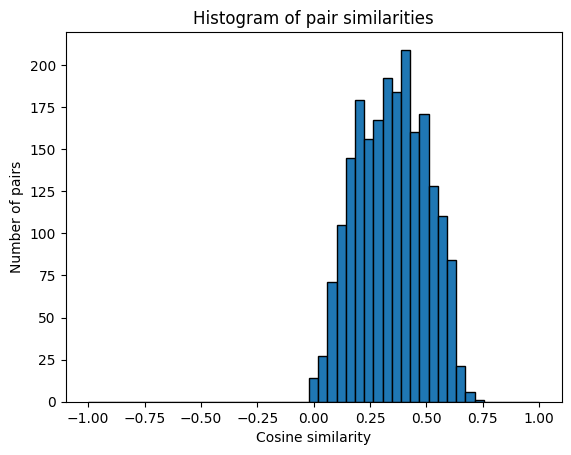

In [35]:
filt_sim = compute_mapped_similarity_local(ad_map_filt, adata_sc, adata_st, 
                                       flavour='spot_to_cell', filter=True)

In [36]:
filt_acc = tgl.compute_annotation_accuracy(
        ad_map_filt,
        adata_sc,
        adata_st,
        flavour='spot_to_cell',
        sc_cluster_label='Allen.subclass_label',
        st_cluster_label='subclass',
        filter=True,
)

Annotation accuracy: 0.002 %


Both metrics testify the worse deterministic alignment obtained with this filter.


# Cell Choice Consistency

In [13]:
hyperparams = tgl.validate_mapping_inputs(
    adata_sc,
    adata_st,
    input_genes=None,
    train_genes_names=None,
    val_genes_names=None,
    mode='filter',
    learning_rate=0.1,
    num_epochs=400,
    lambda_d=1e2,
    lambda_g1=1,
    lambda_g2=1,
    lambda_r=1e-6,
    lambda_l1=0,
    lambda_l2=0,
    lambda_count=1e-5,
    lambda_f_reg=1e-5,
    target_count=None,
    lambda_sparsity_g1=0,
    lambda_neighborhood_g1=0,
    lambda_getis_ord=0,
    lambda_moran=0,
    lambda_geary=0,
    lambda_ct_islands=0,
    cluster_label=None,
    )

In [ ]:
multiple_runs_results = tgl.run_multiple_mappings(adata_sc, adata_st, config=hyperparams,
    n_runs=10,
    compute_mapping_cube=False,
    compute_filtered_cube=False,
    compute_filter_square=True,)


Entering multiple runs training:
Allocating filters square of size =  5.90 MiB ...
Done

Run 1/10...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])
Epoch 0: {'Total loss': 0.05027204751968384, 'Score': 0.5168958902359009, 'KL divergence': 1.3372860848903656e-05, 'Filter term': 36462.421875}
Epoch 100: {'Total loss': -0.30736517906188965, 'Score': 0.6151952743530273, 'KL divergence': 5.520181730389595e-06, 'Filter term': 17486.142578125}
Epoch 200: {'Total loss': -0.3073665201663971, 'Score': 0.6151952743530273, 'KL divergence': 5.507608875632286e-06, 'Filter term': 17486.140625}
Epoch 300: {'Total loss': -0.3073571026325226, 'Score': 0.6151952743530273, 'KL divergence': 5.601672455668449e-06, 'Filter term': 17486.140625}


`Trainer.fit` stopped: `max_epochs=400` reached.



Run 2/10...


...

Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])
Epoch 0: {'Total loss': 0.05130428075790405, 'Score': 0.5168938040733337, 'KL divergence': 1.2766337022185326e-05, 'Filter term': 36550.66015625}
Epoch 100: {'Total loss': -0.30712658166885376, 'Score': 0.6157865524291992, 'KL divergence': 5.554873496294022e-06, 'Filter term': 17555.3203125}
Epoch 200: {'Total loss': -0.30711764097213745, 'Score': 0.6157865524291992, 'KL divergence': 5.644978955388069e-06, 'Filter term': 17555.3203125}
Epoch 300: {'Total loss': -0.3071286678314209, 'Score': 0.6157865524291992, 'KL divergence': 5.535082891583443e-06, 'Filter term': 17555.31640625}


`Trainer.fit` stopped: `max_epochs=400` reached.



Run 5/10...


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name               | Type      | Params | Mode 
---------------------------------------------------------
0 | _density_criterion | KLDivLoss | 0      | train
  | other params       | n/a       | 165 M  | n/a  
---------------------------------------------------------
165 M     Trainable params
0         Non-trainable params
165 M     Total params
660.149   Total estimated model params size (MB)
1         Modules in train mode
0         Modules in eval mode


Training with 252 genes
S matrix shape: torch.Size([77337, 252])
G matrix shape: torch.Size([2133, 252])
Epoch 0: {'Total loss': 0.05090689659118652, 'Score': 0.5169477462768555, 'KL divergence': 1.3038050383329391e-05, 'Filter term': 36510.6171875}


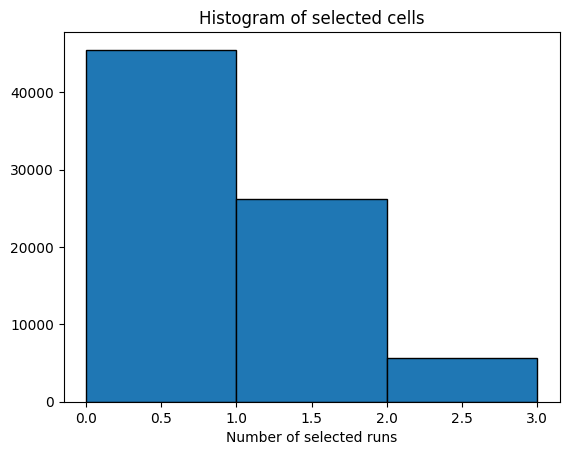

Filter consistency: 0.441 %


In [12]:
cell_choice_cons = tgl.filter_cell_choice_consistency(multiple_runs_results[0])